In [2]:
import healpy
import healpy as hp
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
from functools import partial
import scipy
jax.config.update("jax_enable_x64", True)


dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2
save_path = '/Users/dominiv/sfsu/thesis/figures/'

In [320]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import os
mtn_tzone = ZoneInfo("America/Denver")

t_start = datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=mtn_tzone)
t_stop =  datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=mtn_tzone)
def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

In [321]:
t_start, t_stop

(datetime.datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=zoneinfo.ZoneInfo(key='America/Denver')),
 datetime.datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=zoneinfo.ZoneInfo(key='America/Denver')))

In [322]:
npz_file = '/Users/dominiv/eigsep/data/all_ant_2.npz'
# dtype_r = np.float32
dtype_c = np.complex64
if not os.path.exists(npz_file):
    data = {}
    times = []
    for f in files:
        print(f)
        hdr = read_header(f)
        if unix_time_to_local(hdr['times'][-1:]) < t_start:
            continue
        if unix_time_to_local(hdr['times'][:1]) > t_stop:
            continue
        dat, hdr, meta = io.read_hdf5(f)
        times.append(hdr['times'])
        for k in dat.keys():
            _d = dat[k]
            data[k] = data.get(k, []) + [_d]
    for k, v in data.items():
        data[k] = np.concatenate(v, dtype=dtype_r if len(k) == 1 else dtype_c)
    times = np.concatenate(times)
    local_times = unix_time_to_local(times)
    np.savez(npz_file, times=times, local_times=local_times, freqs=freqs, **data)
else:
    npz = np.load(npz_file, allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    times = data.pop('times')
    local_times = data.pop('local_times')
    freqs = data.pop('freqs')

In [323]:
chs = np.arange(16, 1024, 16)
k_1 = '2'
reduced = data[k_1][:, chs]
reduced = data[k_1][:,chs] - 0.5 * (data[k_1][:,chs-1] + data[k_1][:,chs+1])

In [324]:
f_ind = 44
# f_ind = 52
# f_ind = 61
ch = f_ind
AZ_STEPS = 72  # with endpoint=True
period = 68.78
#t_start = 1753038750 # s utc
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
norm = 1 / np.mean(reduced[:i_start], axis=0, keepdims=True)
norm[:,:4] = 0
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)

valid = np.ones(times.shape, dtype=bool)
valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False
    
valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
sl = slice(i_start, i_stop)
_times = times[sl].copy()
_times -= _times[0]
# optional for strictly data-driven double-period folding
#_times_rnd = np.floor(_times / (2 * period))
#_times_mod = _times - _times_rnd * (2 * period)
val = valid[sl]
print(freqs[::16][ch])

171.875


In [325]:
import aipy
class BeamFit:
    def __init__(self, times, az_steps=AZ_STEPS, lmax=5):
        self.az_steps = az_steps
        self.times = times
        self.lmax = lmax
        self._el_ax = self._ant_pvec = np.array([1, 0, 0], dtype=dtype_r)
        self._az_ax = np.array([0, 0, -1], dtype=dtype_r)
        self.prms = {}
        self.ant_pvec = self.polresp = self.A_Ylm = self.A = None

    def _set_timing_params(self, prms):
        keys = {'t_off', 'el_off', 't_az_step', 'period'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.az_deg = self.el_deg = self.ant_pvec = self.A_Ylm = self.A = None

    def _set_pol_params(self, prms):
        keys = {'prz', 'px', 'py'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.gnd_pvecs = self.polresp = self.A = None

    def set_params(self, prms):
        self._set_timing_params(prms)
        self._set_pol_params(prms)
        
    def build_az_el(self):
        '''Build az/el coordinates.'''
        if self.ant_pvec is not None:
            return
        az, el, inds = [], [], []
        t_off, el_off, t_az_step, period = self.prms['t_off'], self.prms['el_off'], self.prms['t_az_step'], self.prms['period']
        i = 0
        t_i = self.times[0] + t_off
        for cnt, _az in enumerate(np.linspace(-180, 180, self.az_steps, endpoint=True)):
            t_f = t_i + period
            while i < self.times.size and self.times[i] < t_f - t_az_step:
                az.append(_az)
                if cnt % 2 == 0:
                    el.append(-180 + 360 * (self.times[i] - t_i) / (period - t_az_step))
                else:
                    el.append( 180 - 360 * (self.times[i] - t_i) / (period - t_az_step))
                inds.append(i)
                i += 1
            while i < self.times.size and self.times[i] < t_f:
                az.append(_az + (360 / (self.az_steps - 1)) * (self.times[i] - (t_f - t_az_step))/t_az_step)
                el.append(el[-1])
                inds.append(i)
                i += 1
            t_i = t_f
        self.az_deg = np.array(az)
        self.el_deg = np.array(el) + el_off
        self.inds = np.array(inds)
        rot_az = aipy.coord.rot_m(np.deg2rad(self.az_deg), self._az_ax)
        rot_el = aipy.coord.rot_m(np.deg2rad(self.el_deg), self._el_ax)
        self.ant_pvec = np.einsum('pab,pbc,c->pa', rot_el, rot_az, self._ant_pvec)

    


    
    def build_pol_resp(self):
        self.build_az_el()
        if self.polresp is not None:
            return
        pvec = np.array([[self.prms['px'], 0, 0], [0, self.prms['py'], 0]], dtype=dtype_r)
        rot_m = aipy.coord.rot_m(np.deg2rad(self.prms['prz']), np.array([0, 0, 1])).astype(dtype_r)
        self.gnd_pvecs = np.dot(rot_m, pvec.T).T
        if self.gnd_pvecs.ndim == 1:
            self.gnd_pvecs = self.gnd_pvecs[None, :]
        resp = np.dot(self.ant_pvec, self.gnd_pvecs.T)
        self.polresp = np.sum(np.abs(resp)**2, axis=-1)

    def build_A_Ylm(self):
        self.build_az_el()
        if self.A_Ylm is not None:
            return
        phi = np.deg2rad(self.az_deg)
        theta = np.deg2rad(self.el_deg)
        theta = np.mod(theta, 2*np.pi)
        theta = np.where(theta > np.pi, 2*np.pi - theta, theta)
        phi = np.mod(phi, 2*np.pi)
    
        N = theta.size
        P = (self.lmax + 1)**2
        A = np.empty((N, P), dtype=dtype_r)
    
        # Keep track of which column corresponds to which (l,m,kind)
        # kind ∈ {'m0','c','s'} for m=0, cos-like, sin-like
        self._meta = []
        col = 0
        for ell in range(self.lmax + 1):
            # m = 0 term (purely real)
            Y_l0 = sph_harm(0, ell, phi, theta).real
            #Y_l0 *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
            A[:, col] = Y_l0
            self._meta.append((ell, 0, 'm0'))
            col += 1
    
            # m > 0 terms: sqrt(2)*Re and sqrt(2)*Im
            for m in range(1, ell + 1):
                Y_lm = sph_harm(m, ell, phi, theta)  # complex
                #Y_lm *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
                A[:, col] = SQRT2 * Y_lm.real
                A[:, col+1] = SQRT2 * Y_lm.imag
                self._meta.append((ell, m, 'c'))
                self._meta.append((ell, m, 's'))
                col += 2
    
        assert col == P
        self.A_Ylm = A

    def build_A(self):
        self.build_pol_resp()
        self.build_A_Ylm()
        if self.A is not None:
            return
        self.A = self.A_Ylm * self.polresp[:, None]

    def _realcoeff_to_alm(self, coeff):
        """
        Convert real-basis coeffficients (matching design-matrix columns) into a
        healpy alm array (complex, m>=0). For a real sky, alms obey:
          a_{l,-m} = (-1)^m a_{l m}^*
        We only fill m>=0 as healpy expects.
        """
        alm = np.zeros(Alm.getsize(self.lmax), dtype=dtype_c)
        for k, (ell, m, kind) in enumerate(self._meta):
            if m == 0 and kind == 'm0':
                alm[Alm.getidx(self.lmax, ell, 0)] = coeff[k]
            elif kind in ('c'):
                c = coeff[k]
                s = coeff[k + 1]
                a_lm = (c - 1j * s) / SQRT2
                alm[Alm.getidx(self.lmax, ell, m)] = a_lm
        return alm

    def fit_alms(self, ymeas, w=None, reg=None, rcond=1e-10):
        self.build_A()
    
        # Apply weights (as sqrt weights on rows)
        ymeas = ymeas[self.inds]
        if w is None:
            w = np.ones_like(ymeas)
        else:
            w = w[self.inds]
        sqrtw = np.sqrt(w)
        Aw = self.A * sqrtw[:, None]
        yw = ymeas * sqrtw
    
        # Optional ridge regularization: stack sqrt(reg)*I
        if reg is not None and reg > 0:
            P = self.A.shape[1]
            Aw = np.vstack([Aw, np.sqrt(reg) * np.eye(P)])
            yw = np.concatenate([yw, np.zeros(P)])
    
        coeff = np.linalg.lstsq(Aw[self.inds], yw[self.inds], rcond=rcond)[0]
        yhat = self.A @ coeff
        chisq = np.sum(w * (ymeas[self.inds] - yhat[self.inds])**2)
        alm = self._realcoeff_to_alm(coeff)
        return alm, chisq, yhat

In [326]:
t_az_step = 1.7
prms = dict(
    t_az_step = t_az_step, # XXX degenerate with beam width, need empirical measurement
    t_off = -2.4 + t_az_step/2,
    # t_off = -2.0 + t_az_step/2,
    el_off = -4.0,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # el_off = -8.5,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # az_off is unnecessary given fitting of polarization angle
    prz = 0.0,
    px = 1.0,
    py = 0.0,
    period = period,
)

# # force a rebuild
# fitter.ant_pvec = None
# fitter.az_deg = None
# fitter.el_deg = None
# fitter.A_Ylm = None
# fitter.A = None
# fitter.build_az_el()

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()
az_inds = np.deg2rad(fitter.az_deg[fitter.inds])
el_inds = np.deg2rad(fitter.el_deg[fitter.inds])

In [327]:
shift = 12
rot = reduced[:, shift:][sl][val][fitter.inds] #* norm[:, ch]
norm = norm[:, shift:]
outfile = 'figures/'
print(rot.shape, norm.shape)

(4409, 51) (1, 51)


In [328]:
rot_times = times[sl][val][fitter.inds]
rot_freq = freqs[chs[shift:]]
rot_freq.shape

(51,)

## Raw Data

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_38290/3482128818.py:10: RuntimeWarning: divide by zero encountered in log10
  np.log10(full_data),
/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_38290/3482128818.py:10: RuntimeWarning: invalid value encountered in log10
  np.log10(full_data),


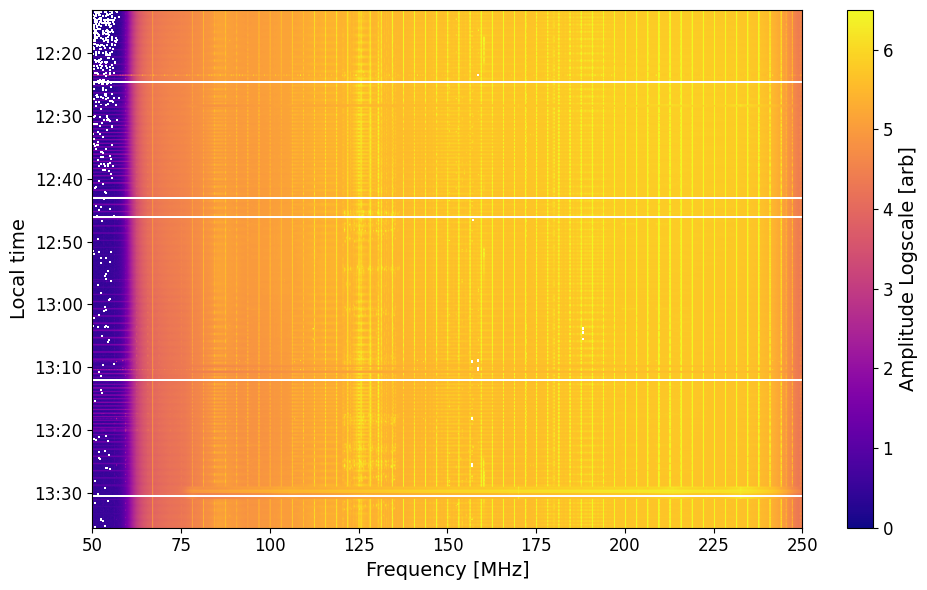

In [314]:
full_data = data[k_1][sl]
full_times = times[sl]
full_freqs = freqs

local_full_times = [datetime.fromtimestamp(t) for t in full_times]

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    np.log10(full_data),
    aspect='auto',
    origin='lower',
    extent=[full_freqs.min(), full_freqs.max(), mdates.date2num(local_full_times[-1]), mdates.date2num(local_full_times[0])],
    # vmin=0, vmax=2.5, cmap='plasma'
    vmin=0, vmax=6.5, cmap='plasma'
)

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Local time", fontsize=14)
# ax.set_title("Sweep Waterfall", fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/full_times
ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Amplitude Logscale [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig(save_path + 'raw_data.pdf')
# plt.savefig('/Users/dominiv/sfsu/cose2026/figures/waterfall.png')
plt.show()

## Waterfall During Rotations

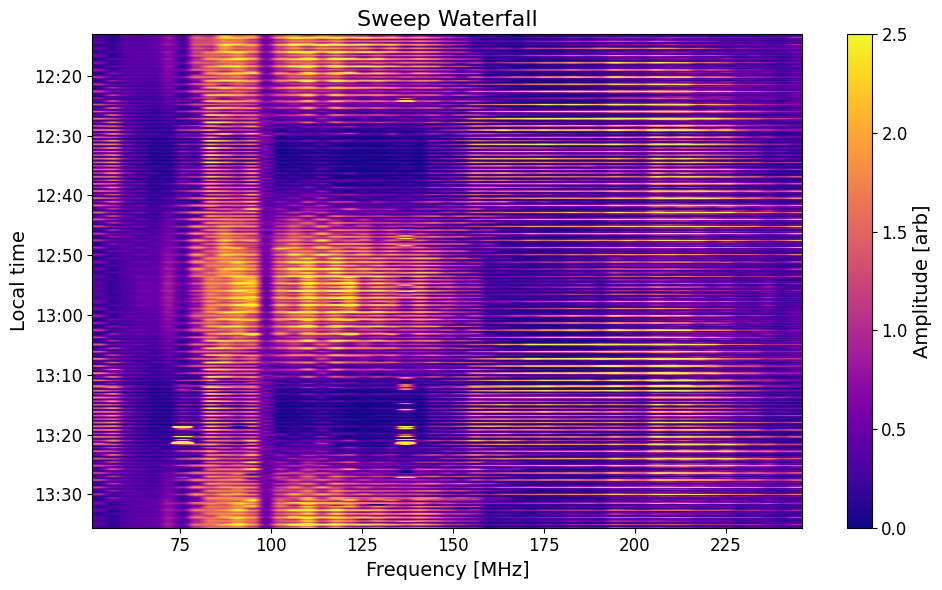

In [227]:
import matplotlib.dates as mdates

local_rot_times = [datetime.fromtimestamp(t) for t in rot_times]

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    rot*norm,
    aspect='auto',
    origin='lower',
    extent=[rot_freq.min(), rot_freq.max(), mdates.date2num(local_rot_times[-1]), mdates.date2num(local_rot_times[0])],
    vmin=0, vmax=2.5, cmap='plasma'
)

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Local time", fontsize=14)
ax.set_title("Sweep Waterfall", fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/rot_times
ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Amplitude [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
# plt.savefig(save_path + 'waterfall.pdf')
# plt.savefig('/Users/dominiv/sfsu/cose2026/figures/waterfall.png')
plt.show()

## El and Az Mapping of One Frequency

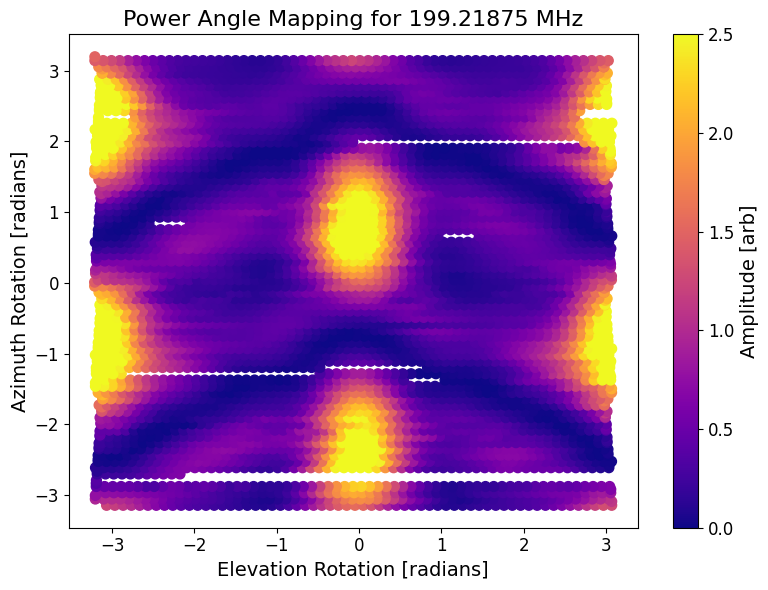

In [329]:
fig_ind = 38
# fig_ind = 13
fig_freq = rot_freq[fig_ind]


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.scatter(el_inds, az_inds,
    c=rot[:, fig_ind]*norm[:, fig_ind],
    vmin=0, vmax=2.5, s=50, cmap='plasma'
)

ax.set_xlabel("Elevation Rotation [radians]", fontsize=14)
ax.set_ylabel("Azimuth Rotation [radians]", fontsize=14)
ax.set_title(f'Power Angle Mapping for {fig_freq} MHz', fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/rot_times
# ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Amplitude [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.savefig(save_path + 'power_scatter.pdf')
# plt.savefig('/Users/dominiv/sfsu/cose2026/figures/power_scatter.png')
plt.tight_layout()
plt.show()

## El and Az Mapping of Multiple Frequencies

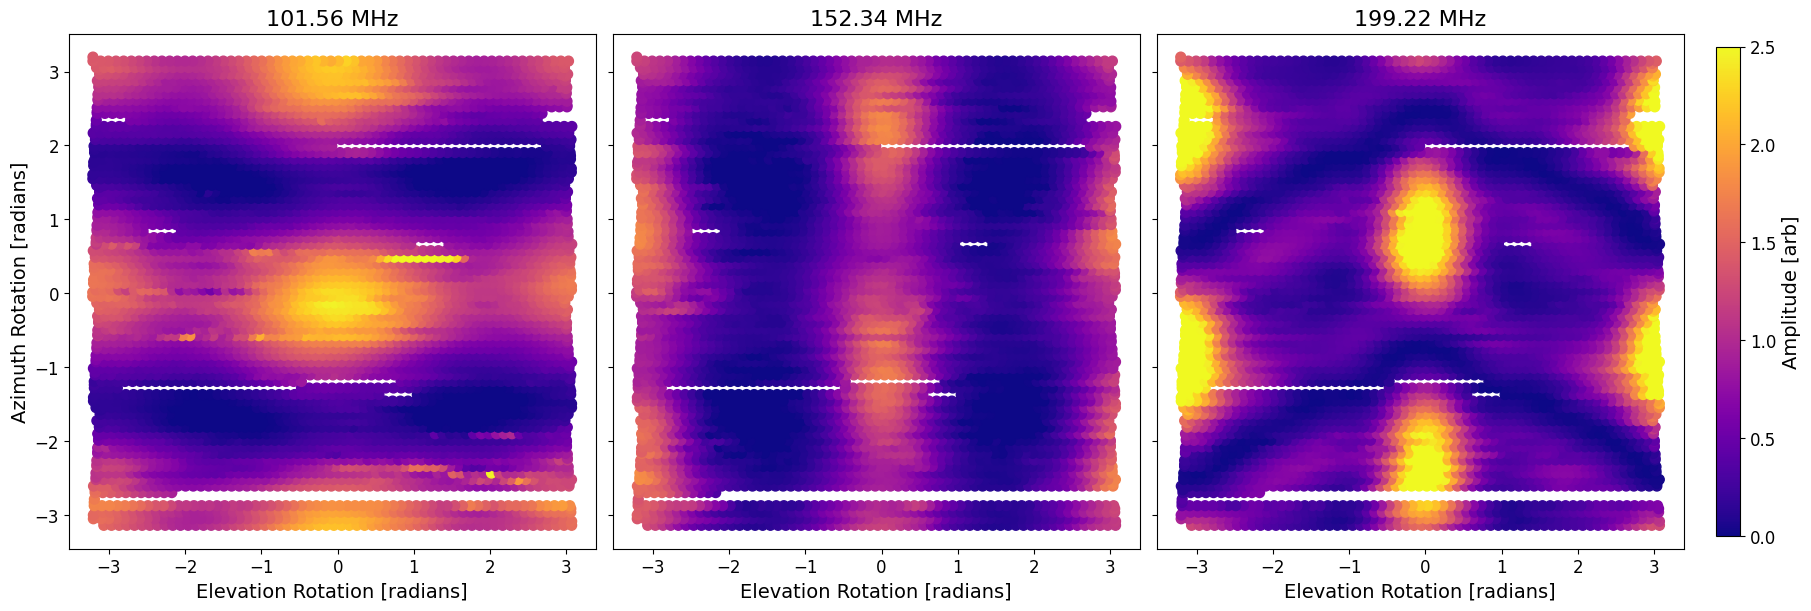

In [340]:
fig_inds = [38, 26, 13]
fig_inds = sorted(fig_inds, key=lambda i: rot_freq[i])

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

vmin, vmax = 0, 2.5
scatter = None

for ax, fig_ind in zip(axes, fig_inds):
    fig_freq = rot_freq[fig_ind]

    scatter = ax.scatter(
        el_inds,
        az_inds,
        c=rot[:, fig_ind] * norm[:, fig_ind],
        vmin=vmin,
        vmax=vmax,
        s=50,
        cmap='plasma'
    )

    ax.set_title(f'{fig_freq:.2f} MHz', fontsize=16)
    ax.set_xlabel("Elevation Rotation [radians]", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

axes[0].set_ylabel("Azimuth Rotation [radians]", fontsize=14)

cbar = fig.colorbar(
    scatter,
    ax=axes,
    location='right',
    shrink=0.95,
    pad=0.02
)
cbar.set_label("Amplitude [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.savefig(save_path + 'power_scatter_3freqs.pdf', bbox_inches='tight')
plt.show()

## Bowtie S11, bot sure if box is present

In [293]:
s11_hfss = np.loadtxt('/Users/dominiv/research/data/original_s11/Copy of S_Parameter_dB.csv', delimiter=',', skiprows=1)

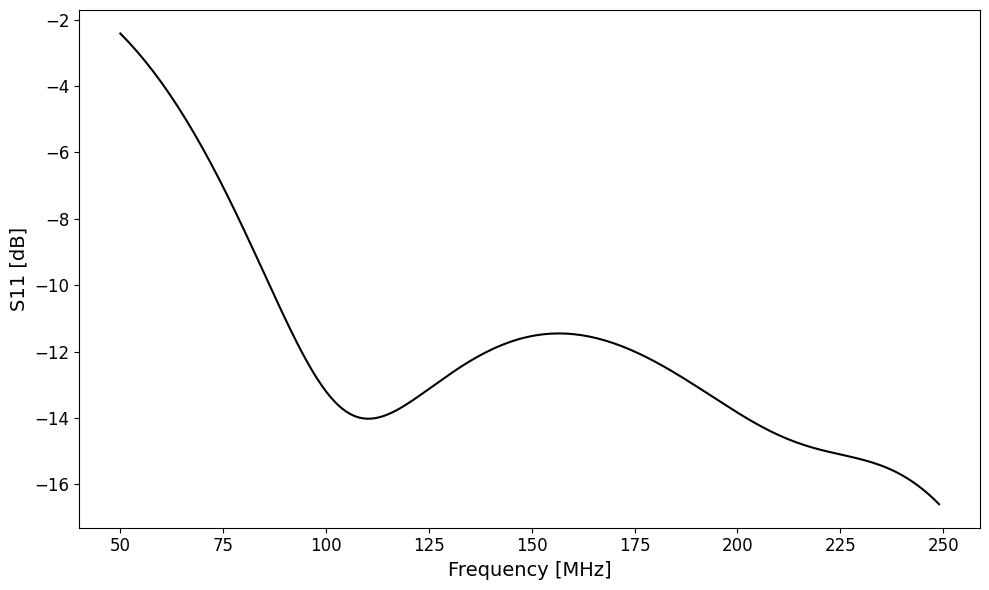

In [298]:
# plt.figure()
# plt.plot(s11[:200, 0], s11[:200, 1])
# # plt.xlim(50, 250)
# # plt.ylim(-20, -2)
# plt.show()
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.plot(s11_hfss[:200, 0], s11_hfss[:200, 1], color='black')

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("S11 [dB]", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(save_path + 'hfss_s11.png')
plt.show()

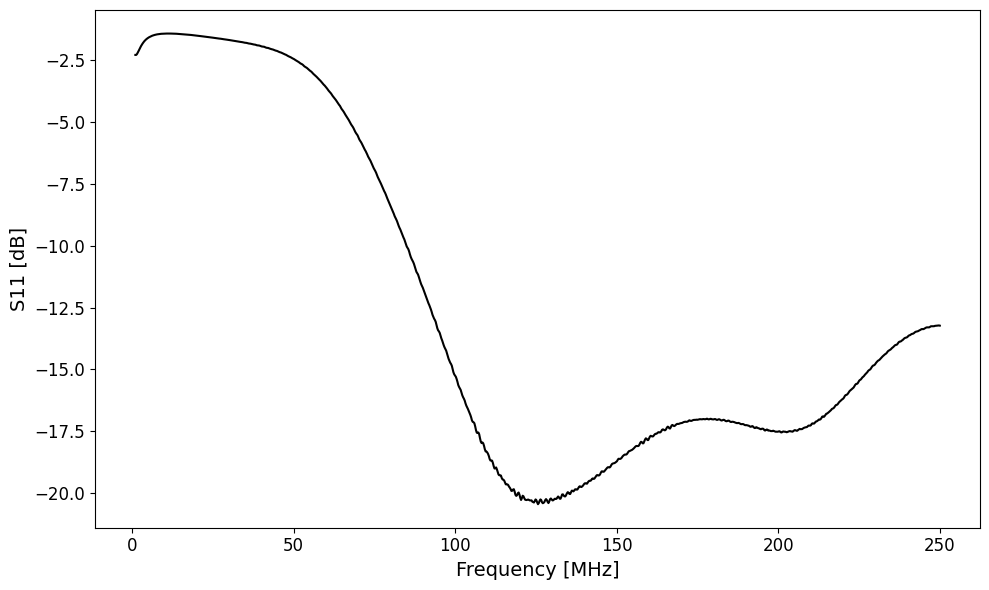

In [299]:
from eigsep_data import S11
from pathlib import Path
def lin2dB(data):
    return 20*np.log10(np.abs(data))
data_dir = Path('/Users/dominiv/eigsep/data/s11_data/')
files = [f for f in data_dir.iterdir() if f.name.startswith("ant")]
s11 = [S11(f) for f in files]
time_ix = np.argsort([s.timestamp for s in s11])
s11 = np.array(s11)[time_ix]
rot_s11 = s11[24] # 24 for some reason? i think im wrong
# plt.figure()
# plt.plot(rot_s11.freqs, lin2dB(rot_s11.s11_cal['ant']))
# plt.show()
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.plot(rot_s11.freqs, lin2dB(rot_s11.s11_cal['ant']), color='black')
# im = ax.plot(s11_hfss[:200, 0], s11_hfss[:200, 1], color='red')

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("S11 [dB]", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(save_path + 'field_s11.png')
plt.show()

## HFSS Simulated Beam Maps

In [73]:
beam_maps_th = np.load('/Users/dominiv/eigsep/data/beam_th.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_ph = np.load('/Users/dominiv/eigsep/data/beam_ph.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
gain_maps = beam_maps_th + beam_maps_ph
empty_beam = jnp.full_like(DEFAULT_BEAM_PHI, hp.UNSEEN)

In [74]:
from pathlib import Path
import numpy as np
import re

def load_antenna_beam_components(folder, skiprows=1):
    """
    Load antenna beam component CSV files into 6 arrays of shape (n_orientations, ndata).

    Filename example
    ----------------
    Re_Ex_100MHz_Phi_90_Theta_90.csv

    Meaning:
    - Re / Im and Ex / Ey / Ez specify the beam component
    - Phi_..._Theta_... in the filename are the PHYSICAL antenna orientation
    - Inside the file:
        col 0 = phi   (spherical map coordinate)
        col 1 = theta (spherical map coordinate)
        col 2 = value

    Assumptions
    -----------
    - All files share the same internal phi/theta columns
    - One frequency per folder
    - There are 6 files for each physical orientation

    Returns
    -------
    map_phi : ndarray, shape (ndata,)
        Shared spherical-map phi values
    map_theta : ndarray, shape (ndata,)
        Shared spherical-map theta values
    orientation_phi : ndarray, shape (n_orientations,)
        Physical antenna phi for each row
    orientation_theta : ndarray, shape (n_orientations,)
        Physical antenna theta for each row
    Re_Ex, Re_Ey, Re_Ez, Im_Ex, Im_Ey, Im_Ez : ndarray
        Each has shape (n_orientations, ndata)
    frequency : str
        Parsed frequency label from filenames
    """

    folder = Path(folder)

    pattern = re.compile(
        r'^(Re|Im)_(Ex|Ey|Ez)_(.+?)_Phi_([-+]?\d*\.?\d+)_Theta_([-+]?\d*\.?\d+)\.csv$',
        re.IGNORECASE
    )

    # Store data by physical orientation
    data_by_orientation = {}
    frequency = None

    map_phi = None
    map_theta = None
    ndata = None

    for file in sorted(folder.glob("*.csv")):
        m = pattern.match(file.name)
        if not m:
            continue

        part, comp, freq, phys_phi, phys_theta = m.groups()
        part = part.capitalize()              # Re / Im
        comp = comp[0] + comp[1:].lower()    # Ex / Ey / Ez
        phys_phi = float(phys_phi)
        phys_theta = float(phys_theta)

        if frequency is None:
            frequency = freq
        elif freq != frequency:
            raise ValueError(f"Multiple frequencies found: {frequency} and {freq}")

        data = np.loadtxt(file, delimiter=",", skiprows=skiprows)

        if data.ndim != 2 or data.shape[1] < 3:
            raise ValueError(f"{file.name} must have at least 3 columns.")

        phi = data[:, 0]
        theta = data[:, 1]
        values = data[:, 2]

        if map_phi is None:
            map_phi = phi.copy()
            map_theta = theta.copy()
            ndata = len(values)
        else:
            if len(values) != ndata:
                raise ValueError(f"{file.name}: row count does not match the first file.")
            if not np.allclose(phi, map_phi) or not np.allclose(theta, map_theta):
                raise ValueError(f"{file.name}: internal phi/theta grid does not match the first file.")

        key = (phys_phi, phys_theta)

        if key not in data_by_orientation:
            data_by_orientation[key] = {
                "Re": {"Ex": None, "Ey": None, "Ez": None},
                "Im": {"Ex": None, "Ey": None, "Ez": None},
            }

        if data_by_orientation[key][part][comp] is not None:
            raise ValueError(f"Duplicate file for orientation {key}, component {part}_{comp}")

        data_by_orientation[key][part][comp] = values

    if not data_by_orientation:
        raise FileNotFoundError("No matching CSV files were found.")

    # One row per physical orientation
    orientation_keys = sorted(data_by_orientation.keys(), key=lambda x: (x[0], x[1]))
    n_orientations = len(orientation_keys)

    orientation_phi = np.array([k[0] for k in orientation_keys], dtype=float)
    orientation_theta = np.array([k[1] for k in orientation_keys], dtype=float)

    Re_Ex = np.empty((n_orientations, ndata))
    Re_Ey = np.empty((n_orientations, ndata))
    Re_Ez = np.empty((n_orientations, ndata))
    Im_Ex = np.empty((n_orientations, ndata))
    Im_Ey = np.empty((n_orientations, ndata))
    Im_Ez = np.empty((n_orientations, ndata))

    for i, key in enumerate(orientation_keys):
        entry = data_by_orientation[key]

        missing = []
        for part in ("Re", "Im"):
            for comp in ("Ex", "Ey", "Ez"):
                if entry[part][comp] is None:
                    missing.append(f"{part}_{comp}")

        if missing:
            raise ValueError(f"Missing components for orientation {key}: {', '.join(missing)}")

        Re_Ex[i, :] = entry["Re"]["Ex"]
        Re_Ey[i, :] = entry["Re"]["Ey"]
        Re_Ez[i, :] = entry["Re"]["Ez"]
        Im_Ex[i, :] = entry["Im"]["Ex"]
        Im_Ey[i, :] = entry["Im"]["Ey"]
        Im_Ez[i, :] = entry["Im"]["Ez"]

    return (
        map_phi,
        map_theta,
        orientation_phi,
        orientation_theta,
        Re_Ex,
        Re_Ey,
        Re_Ez,
        Im_Ex,
        Im_Ey,
        Im_Ez,
        frequency,
    )

(
    map_phi,
    map_theta,
    orientation_phi,
    orientation_theta,
    Re_Ex,
    Re_Ey,
    Re_Ez,
    Im_Ex,
    Im_Ey,
    Im_Ez,
    frequency,
) = load_antenna_beam_components("/Users/dominiv/research/data/rot_beam/ElectricPatterns_100MHz/", skiprows=1)

print(Re_Ex.shape)   # (361, ndata)   for example
print(Im_Ez.shape)   # (361, ndata)
print(map_phi.shape) # (ndata,)
print(map_theta.shape)

def load_total_gain(folder, skiprows=1):
    """
    Load total-gain CSV files into one array of shape (n_orientations, ndata).

    Expected filename example
    -------------------------
    Gain_100MHz_Phi_90_Theta_90.csv

    Assumed meaning:
    - Phi_..._Theta_... in the filename are the PHYSICAL antenna orientation
    - Inside the file:
        col 0 = phi   (spherical map coordinate)
        col 1 = theta (spherical map coordinate)
        col 2 = gain value

    Assumptions
    -----------
    - All files share the same internal phi/theta columns
    - One frequency per folder
    - One file per physical orientation

    Returns
    -------
    map_phi : ndarray, shape (ndata,)
    map_theta : ndarray, shape (ndata,)
    orientation_phi : ndarray, shape (n_orientations,)
    orientation_theta : ndarray, shape (n_orientations,)
    gain : ndarray, shape (n_orientations, ndata)
    frequency : str
    """

    folder = Path(folder)

    # pattern = re.compile(
        # r'^(.+?)_Phi_([-+]?\d*\.?\d+)_Theta_([-+]?\d*\.?\d+)\.csv$',
        # re.IGNORECASE
    # )
    pattern = re.compile(
        r'^Total_Abs_Gain_(.+?)_Phi_([-+]?\d*\.?\d+)_Theta_([-+]?\d*\.?\d+)\.csv$',
        re.IGNORECASE
    )
    data_by_orientation = {}
    frequency = None
    map_phi = None
    map_theta = None
    ndata = None

    for file in sorted(folder.glob("*.csv")):
        m = pattern.match(file.name)
        if not m:
            continue

        freq_label, phys_phi, phys_theta = m.groups()
        phys_phi = float(phys_phi)
        phys_theta = float(phys_theta)

        if frequency is None:
            frequency = freq_label
        elif freq_label != frequency:
            raise ValueError(f"Multiple frequencies found: {frequency} and {freq_label}")

        data = np.loadtxt(file, delimiter=",", skiprows=skiprows)

        if data.ndim != 2 or data.shape[1] < 3:
            raise ValueError(f"{file.name} must have at least 3 columns.")

        phi = data[:, 0]
        theta = data[:, 1]
        values = data[:, 2]

        if map_phi is None:
            map_phi = phi.copy()
            map_theta = theta.copy()
            ndata = len(values)
        else:
            if len(values) != ndata:
                raise ValueError(f"{file.name}: row count does not match the first file.")
            if not np.allclose(phi, map_phi) or not np.allclose(theta, map_theta):
                raise ValueError(f"{file.name}: internal phi/theta grid does not match the first file.")

        key = (phys_phi, phys_theta)

        if key in data_by_orientation:
            raise ValueError(f"Duplicate gain file for orientation {key}")

        data_by_orientation[key] = values

    if not data_by_orientation:
        raise FileNotFoundError("No matching CSV files were found.")

    orientation_keys = sorted(data_by_orientation.keys(), key=lambda x: (x[0], x[1]))
    n_orientations = len(orientation_keys)

    orientation_phi = np.array([k[0] for k in orientation_keys], dtype=float)
    orientation_theta = np.array([k[1] for k in orientation_keys], dtype=float)

    gain = np.empty((n_orientations, ndata))

    for i, key in enumerate(orientation_keys):
        gain[i, :] = data_by_orientation[key]

    return map_phi, map_theta, orientation_phi, orientation_theta, gain, frequency

(
    map_phi,
    map_theta,
    orientation_phi,
    orientation_theta,
    all_gain,
    frequency,
) = load_total_gain("/Users/dominiv/research/data/rot_beam/GainPatterns_100MHz/", skiprows=1)

print(all_gain.shape)  # (361, ndata)

bowtie_theta_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_250MHz.csv', delimiter=',', skiprows=1)

bowtie_phi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_250MHz.csv', delimiter=',', skiprows=1)

bowtie_x_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_100MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_150MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_200MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_250MHz.csv', delimiter=',', skiprows=1)

bowtie_y_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_100MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_150MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_200MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_250MHz.csv', delimiter=',', skiprows=1)

bowtie_z_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_100MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_150MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_200MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_250MHz.csv', delimiter=',', skiprows=1)

dipole_theta_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_250MHz.csv', delimiter=',', skiprows=1)

dipole_phi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_250MHz.csv', delimiter=',', skiprows=1)

dipole_theta_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Theta_Imaginaryl_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Theta_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Phi_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Phi_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Theta_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Theta_Real_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Phi_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Phi_Real_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Theta_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Theta_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Phi_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Phi_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Theta_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Theta_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Phi_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Phi_Real_250MHz.csv', delimiter=',', skiprows=1)

dipole_x_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_100MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_150MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_200MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_250MHz.csv', delimiter=',', skiprows=1)

dipole_y_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_100MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_150MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_200MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_250MHz.csv', delimiter=',', skiprows=1)

dipole_z_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_100MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_150MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_200MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_250MHz.csv', delimiter=',', skiprows=1)

### check file names, i think i messed some up
bowtie_theta_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Theta_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Theta_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Phi_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Phi_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Theta_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Theta_Real_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Phi_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Phi_Real_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Theta_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Theta_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Phi_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Phi_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Theta_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Theta_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Phi_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Phi_Real_250MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_X_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_X_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Y_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Y_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Z_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Z_Imaginary_100MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_X_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_X_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Y_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Y_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Z_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Z_Imaginary_100MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_X_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_X_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Y_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Y_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Z_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Z_Imaginary_200MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_X_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_X_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Y_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Y_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Z_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Z_Imaginary_200MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_X_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_X_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Y_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Y_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Z_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Z_Imaginary_250MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_X_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_X_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Y_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Y_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Z_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Z_Imaginary_250MHz.csv', delimiter=',', skiprows=1)

nside = DEFAULT_NSIDE
npix = hp.nside2npix(nside)
beam_thetas = np.deg2rad(bowtie_x_gain_100[:, 1])
beam_phis =   np.deg2rad(bowtie_x_gain_100[:, 0])

def hfss_map(gain, k=8):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas, beam_phis))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    # k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap


# ek = 1
ek = 8

bowtie_x_beam_100 = hfss_map(bowtie_x_gain_100)
bowtie_x_beam_150 = hfss_map(bowtie_x_gain_150)
bowtie_x_beam_200 = hfss_map(bowtie_x_gain_200)
bowtie_x_beam_250 = hfss_map(bowtie_x_gain_250)

bowtie_y_beam_100 = hfss_map(bowtie_y_gain_100)
bowtie_y_beam_150 = hfss_map(bowtie_y_gain_150)
bowtie_y_beam_200 = hfss_map(bowtie_y_gain_200)
bowtie_y_beam_250 = hfss_map(bowtie_y_gain_250)

bowtie_z_beam_100 = hfss_map(bowtie_z_gain_100)
bowtie_z_beam_150 = hfss_map(bowtie_z_gain_150)
bowtie_z_beam_200 = hfss_map(bowtie_z_gain_200)
bowtie_z_beam_250 = hfss_map(bowtie_z_gain_250)

dipole_x_beam_100 = hfss_map(dipole_x_gain_100)
dipole_x_beam_150 = hfss_map(dipole_x_gain_150)
dipole_x_beam_200 = hfss_map(dipole_x_gain_200)
dipole_x_beam_250 = hfss_map(dipole_x_gain_250)

dipole_y_beam_100 = hfss_map(dipole_y_gain_100)
dipole_y_beam_150 = hfss_map(dipole_y_gain_150)
dipole_y_beam_200 = hfss_map(dipole_y_gain_200)
dipole_y_beam_250 = hfss_map(dipole_y_gain_250)

dipole_z_beam_100 = hfss_map(dipole_z_gain_100)
dipole_z_beam_150 = hfss_map(dipole_z_gain_150)
dipole_z_beam_200 = hfss_map(dipole_z_gain_200)
dipole_z_beam_250 = hfss_map(dipole_z_gain_250)

bowtie_theta_beam_100 = hfss_map(bowtie_theta_gain_100)
bowtie_theta_beam_150 = hfss_map(bowtie_theta_gain_150)
bowtie_theta_beam_200 = hfss_map(bowtie_theta_gain_200)
bowtie_theta_beam_250 = hfss_map(bowtie_theta_gain_250)

bowtie_phi_beam_100 = hfss_map(bowtie_phi_gain_100)
bowtie_phi_beam_150 = hfss_map(bowtie_phi_gain_150)
bowtie_phi_beam_200 = hfss_map(bowtie_phi_gain_200)
bowtie_phi_beam_250 = hfss_map(bowtie_phi_gain_250)

dipole_theta_imag_100_map = hfss_map(dipole_theta_imag_100, k=ek)
dipole_theta_real_100_map = hfss_map(dipole_theta_real_100, k=ek)
dipole_phi_imag_100_map = hfss_map(dipole_phi_imag_100, k=ek)
dipole_phi_real_100_map = hfss_map(dipole_phi_real_100, k=ek)

bowtie_theta_imag_100_map = hfss_map(bowtie_theta_imag_100, k=ek)
bowtie_theta_real_100_map = hfss_map(bowtie_theta_real_100, k=ek)
bowtie_phi_imag_100_map =   hfss_map(bowtie_phi_imag_100, k=ek)
bowtie_phi_real_100_map =   hfss_map(bowtie_phi_real_100, k=ek)

dipole_theta_imag_150_map = hfss_map(dipole_theta_imag_150)
dipole_theta_real_150_map = hfss_map(dipole_theta_real_150)
dipole_phi_imag_150_map =   hfss_map(dipole_phi_imag_150)
dipole_phi_real_150_map =   hfss_map(dipole_phi_real_150)

bowtie_theta_imag_150_map = hfss_map(bowtie_theta_imag_150)
bowtie_theta_real_150_map = hfss_map(bowtie_theta_real_150)
bowtie_phi_imag_150_map =   hfss_map(bowtie_phi_imag_150)
bowtie_phi_real_150_map =   hfss_map(bowtie_phi_real_150)

dipole_theta_imag_200_map = hfss_map(dipole_theta_imag_200)
dipole_theta_real_200_map = hfss_map(dipole_theta_real_200)
dipole_phi_imag_200_map =   hfss_map(dipole_phi_imag_200)
dipole_phi_real_200_map =   hfss_map(dipole_phi_real_200)

bowtie_theta_imag_200_map = hfss_map(bowtie_theta_imag_200)
bowtie_theta_real_200_map = hfss_map(bowtie_theta_real_200)
bowtie_phi_imag_200_map =   hfss_map(bowtie_phi_imag_200)
bowtie_phi_real_200_map =   hfss_map(bowtie_phi_real_200)

dipole_theta_imag_250_map = hfss_map(dipole_theta_imag_250)
dipole_theta_real_250_map = hfss_map(dipole_theta_real_250)
dipole_phi_imag_250_map =   hfss_map(dipole_phi_imag_250)
dipole_phi_real_250_map =   hfss_map(dipole_phi_real_250)

bowtie_theta_imag_250_map = hfss_map(bowtie_theta_imag_250)
bowtie_theta_real_250_map = hfss_map(bowtie_theta_real_250)
bowtie_phi_imag_250_map =   hfss_map(bowtie_phi_imag_250)
bowtie_phi_real_250_map =   hfss_map(bowtie_phi_real_250)

dipole_xi_beam_100 = hfss_map(dipole_xi_gain_100, k=ek)
dipole_xr_beam_100 = hfss_map(dipole_xr_gain_100, k=ek)
dipole_yi_beam_100 = hfss_map(dipole_yi_gain_100, k=ek)
dipole_yr_beam_100 = hfss_map(dipole_yr_gain_100, k=ek)
dipole_zi_beam_100 = hfss_map(dipole_zi_gain_100, k=ek)
dipole_zr_beam_100 = hfss_map(dipole_zr_gain_100, k=ek)

bowtie_xi_beam_100 = hfss_map(bowtie_xi_gain_100, k=ek)
bowtie_xr_beam_100 = hfss_map(bowtie_xr_gain_100, k=ek)
bowtie_yi_beam_100 = hfss_map(bowtie_yi_gain_100, k=ek)
bowtie_yr_beam_100 = hfss_map(bowtie_yr_gain_100, k=ek)
bowtie_zi_beam_100 = hfss_map(bowtie_zi_gain_100, k=ek)
bowtie_zr_beam_100 = hfss_map(bowtie_zr_gain_100, k=ek)

dipole_xi_beam_200 = hfss_map(dipole_xi_gain_200, k=ek)
dipole_xr_beam_200 = hfss_map(dipole_xr_gain_200, k=ek)
dipole_yi_beam_200 = hfss_map(dipole_yi_gain_200, k=ek)
dipole_yr_beam_200 = hfss_map(dipole_yr_gain_200, k=ek)
dipole_zi_beam_200 = hfss_map(dipole_zi_gain_200, k=ek)
dipole_zr_beam_200 = hfss_map(dipole_zr_gain_200, k=ek)

bowtie_xi_beam_200 = hfss_map(bowtie_xi_gain_200, k=ek)
bowtie_xr_beam_200 = hfss_map(bowtie_xr_gain_200, k=ek)
bowtie_yi_beam_200 = hfss_map(bowtie_yi_gain_200, k=ek)
bowtie_yr_beam_200 = hfss_map(bowtie_yr_gain_200, k=ek)
bowtie_zi_beam_200 = hfss_map(bowtie_zi_gain_200, k=ek)
bowtie_zr_beam_200 = hfss_map(bowtie_zr_gain_200, k=ek)

dipole_xi_beam_250 = hfss_map(dipole_xi_gain_250, k=ek)
dipole_xr_beam_250 = hfss_map(dipole_xr_gain_250, k=ek)
dipole_yi_beam_250 = hfss_map(dipole_yi_gain_250, k=ek)
dipole_yr_beam_250 = hfss_map(dipole_yr_gain_250, k=ek)
dipole_zi_beam_250 = hfss_map(dipole_zi_gain_250, k=ek)
dipole_zr_beam_250 = hfss_map(dipole_zr_gain_250, k=ek)

bowtie_xi_beam_250 = hfss_map(bowtie_xi_gain_250, k=ek)
bowtie_xr_beam_250 = hfss_map(bowtie_xr_gain_250, k=ek)
bowtie_yi_beam_250 = hfss_map(bowtie_yi_gain_250, k=ek)
bowtie_yr_beam_250 = hfss_map(bowtie_yr_gain_250, k=ek)
bowtie_zi_beam_250 = hfss_map(bowtie_zi_gain_250, k=ek)
bowtie_zr_beam_250 = hfss_map(bowtie_zr_gain_250, k=ek)

dipole_theta_beam_100 = hfss_map(dipole_theta_gain_100)
dipole_phi_beam_100 = hfss_map(dipole_phi_gain_100)

bowtie_realized_gain100 = np.loadtxt('/Users/dominiv/research/data/Realized_Gain_100MHz_Phi_0_Theta_90.csv', delimiter=',', skiprows=1)
bowtie_realized_gain100_map = hfss_map(bowtie_realized_gain100)

(361, 16471)
(361, 16471)
(16471,)
(16471,)
(361, 16471)


In [75]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
s11_aut = np.loadtxt( '/Users/dominiv/research/data/S11_AUT.csv', delimiter=',', skiprows=1)
s12_atu_t = np.loadtxt('/Users/dominiv/research/data/S12_AUT_to_Trans.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361

In [76]:
phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])
freqs = s11_transmitter[:inc, 2]

def db_lin(db):
    # return 10**(db/10)
    return db

s11_t = db_lin(s11_transmitter[:, 3])
s11_t = s11_t.reshape(ang, inc)
# s11_t = np.reshape(s11_t, newshape=(inc, s11_t.shape[0]//inc))

s11_bowtie = db_lin(s11_aut[:, 3])
s11_bowtie = s11_bowtie.reshape(ang, inc)
# s11_bowtie = np.reshape(s11_bowtie, newshape=(inc, s11_bowtie.shape[0]//inc))

s12_bowtie = db_lin(s12_atu_t[:, 3])
s12_bowtie = s12_bowtie.reshape(ang, inc)
# s12_bowtie = np.reshape(s12_bowtie, newshape=(inc, s12_bowtie.shape[0]//inc))

def hfss_map_gain_only(gain, k=8):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas, beam_phis))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    # k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[idx]).sum(axis=1)
    return hmap

Re_Ex_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)
Re_Ey_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)
Re_Ez_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)
Im_Ex_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)
Im_Ey_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)
Im_Ez_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)
all_gain_maps = jnp.full(shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]), fill_value=hp.UNSEEN)

for i in range(Re_Ex.shape[0]):
    Re_Ex_maps = Re_Ex_maps.at[i].set(hfss_map_gain_only(Re_Ex[i], ek))
    Re_Ey_maps = Re_Ey_maps.at[i].set(hfss_map_gain_only(Re_Ey[i], ek))
    Re_Ez_maps = Re_Ez_maps.at[i].set(hfss_map_gain_only(Re_Ez[i], ek))
    Im_Ex_maps = Im_Ex_maps.at[i].set(hfss_map_gain_only(Im_Ex[i], ek))
    Im_Ey_maps = Im_Ey_maps.at[i].set(hfss_map_gain_only(Im_Ey[i], ek))
    Im_Ez_maps = Im_Ez_maps.at[i].set(hfss_map_gain_only(Im_Ez[i], ek))
    all_gain_maps = all_gain_maps.at[i].set(hfss_map_gain_only(all_gain[i], ek))





print(Re_Ex_maps.shape)

Ex_Rx = Re_Ex_maps + 1j*Im_Ex_maps
Ey_Rx = Re_Ey_maps + 1j*Im_Ey_maps
Ez_Rx = Re_Ez_maps + 1j*Im_Ez_maps

Ex_Tx = dipole_xr_beam_100 + 1j*dipole_xi_beam_100
Ey_Tx = dipole_yr_beam_100 + 1j*dipole_yi_beam_100
Ez_Tx = dipole_zr_beam_100 + 1j*dipole_zi_beam_100

(361, 12288)


In [115]:
Ex = Re_Ex + 1j*Im_Ex
Ey = Re_Ey + 1j*Im_Ey
Ez = Re_Ez + 1j*Im_Ez


Ebeam_r = (
    Ex * np.sin(beam_thetas) * np.cos(beam_phis)
    + Ey * np.sin(beam_thetas) * np.sin(beam_phis)
    + Ez * np.cos(beam_thetas)
)

Ebeam_thetas = (
    Ex * np.cos(beam_thetas) * np.cos(beam_phis)
    + Ey * np.cos(beam_thetas) * np.sin(beam_phis)
    - Ez * np.sin(beam_thetas)
)

Ebeam_phis = (
    -Ex * np.sin(beam_phis)
    + Ey * np.cos(beam_phis)
)

Etheta = jnp.full(
    shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]),
    fill_value=hp.UNSEEN + 0j,
    dtype=jnp.complex128,
)

Ephi = jnp.full(
    shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]),
    fill_value=hp.UNSEEN + 0j,
    dtype=jnp.complex128,
)

Er = jnp.full(
    shape=(Re_Ex.shape[0], dipole_theta_beam_100.shape[0]),
    fill_value=hp.UNSEEN + 0j,
    dtype=jnp.complex128,
)

for i in range(Re_Ex.shape[0]):
    Etheta = Etheta.at[i].set(hfss_map_gain_only(Ebeam_thetas[i], ek))
    Ephi = Ephi.at[i].set(hfss_map_gain_only(Ebeam_phis[i], ek))
    Er = Er.at[i].set(hfss_map_gain_only(Ebeam_r[i], ek))

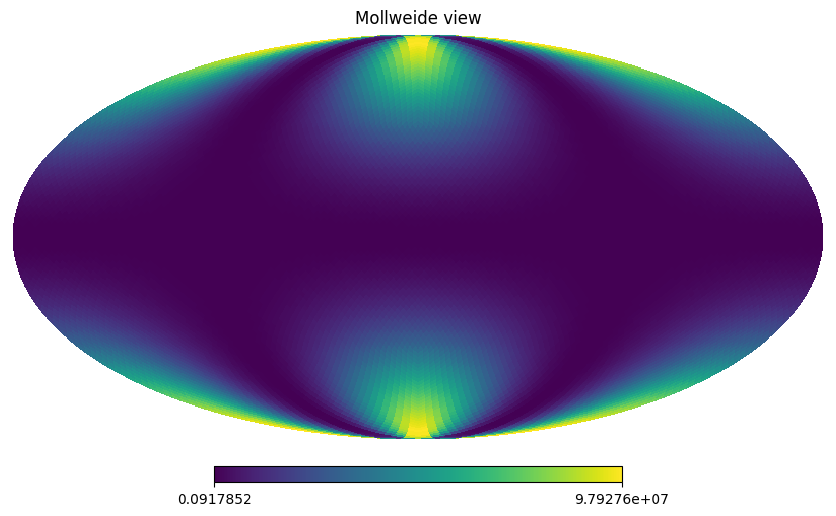

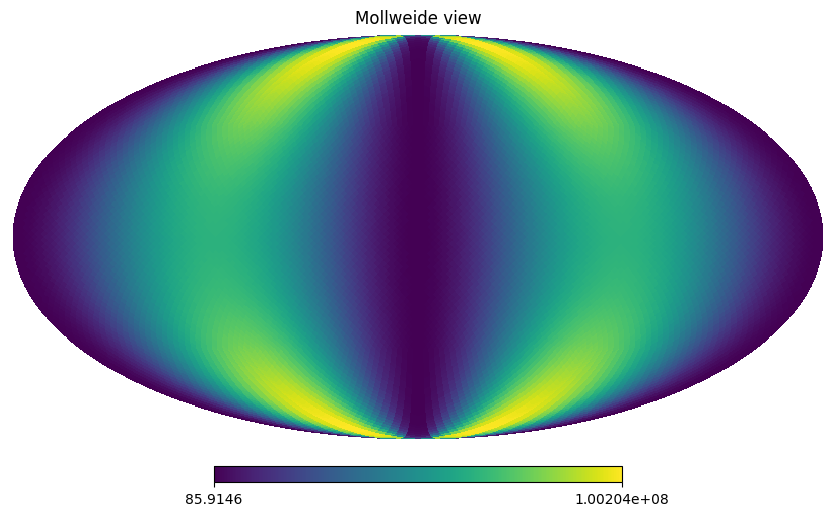

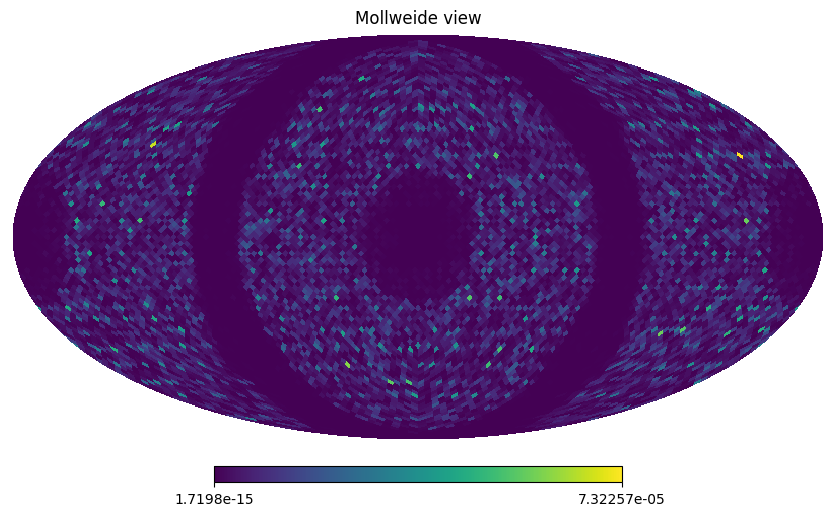

In [117]:
hp.mollview(jnp.abs(Etheta[flat])**2)
hp.mollview(jnp.abs(Ephi[flat])**2)
hp.mollview(jnp.abs(Er[flat])**2)

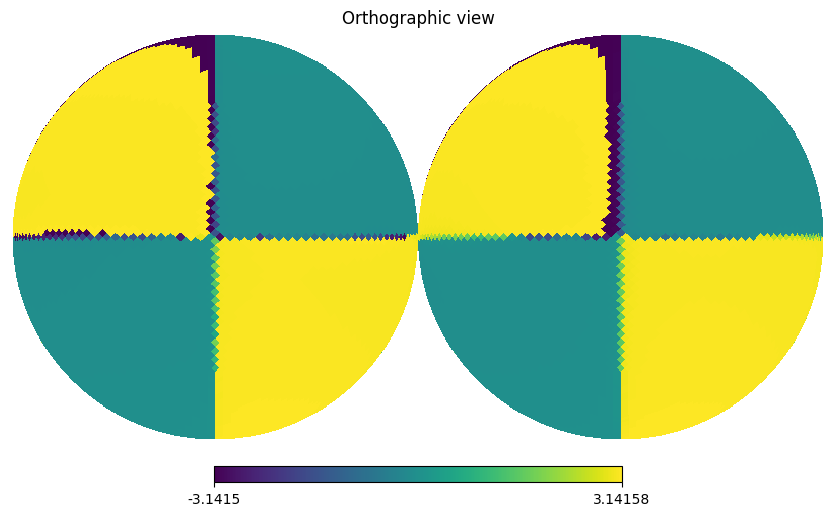

In [122]:
flat = 9 ### antenna is flat in the same orientation of our experiment set up
phase_angx = np.angle(Ex_Rx)
phase_angy = np.angle(Ey_Rx)
phase_angz = np.angle(Ez_Rx)

phase_angt = np.angle(Etheta)
phase_angp = np.angle(Ephi)
phase_angr = np.angle(Er)

rel_phase = np.angle(Etheta*np.conj(Ephi))
# hp.mollview(phase_angx[flat])
# hp.mollview(phase_angy[flat])
# hp.mollview(phase_angz[flat])
# hp.mollview(phase_angt[flat])
# hp.mollview(phase_angp[flat])
# hp.mollview(phase_angr[flat])
# hp.mollview(rel_phase[flat])
hp.orthview(rel_phase[flat])

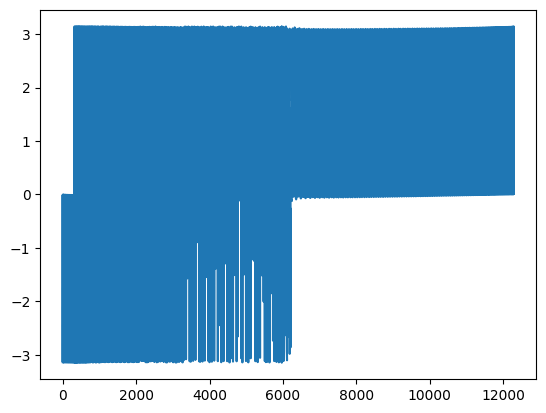

In [120]:
plt.figure()
plt.plot(rel_phase[flat])
# plt.plot(phase_angx[flat])
# plt.plot(phase_angy[flat])
# plt.plot(phase_angz[flat])
plt.show()

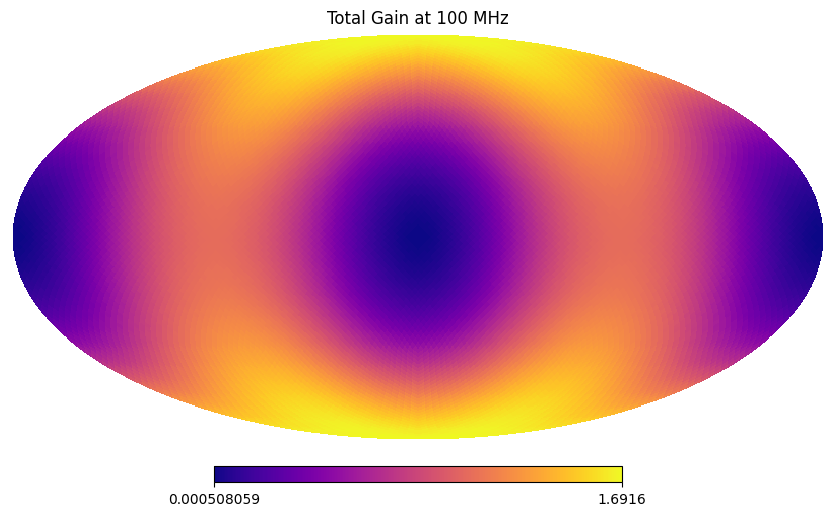

In [77]:
flat = 9
# print(jnp.where(thetas==jnp.pi/2), jnp.where(phis==0))
s11_b100 = 1-10**(s11_bowtie[:, 50]/10)
# s11_t100 = 1-jnp.abs(s11_t[:, 50])**2
s11_t100 = 1-10**(s11_t[:, 50]/10)
mu0 = 12.566e-7
eps0 = 8.854e-12
eta0 = jnp.sqrt(mu0 / eps0)
# Pinc = 1.0 * s11_b100[flat]
# Pinc = s11_b100[flat]
Pinc = 1
# Pinc = s11_b100[flat]
# Pinc = 1 - jnp.abs(s11_bowtie[flat, 50])**2
# Pinc = 1.0 / 1.1425
K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
# K_E = 4 * jnp.pi / (  Pinc)
test_E = ((jnp.abs(Ex_Rx[flat]*1e-3))**2 + (jnp.abs(Ey_Rx[flat]*1e-3))**2 + (jnp.abs(Ez_Rx[flat]*1e-3))**2)*K_E * (s11_b100[flat])
scale_factor = all_gain_maps[flat] / test_E
hp.mollview(test_E, cmap='plasma', title='Total Gain at 100 MHz')
# plt.savefig(save_path + 'hfss_100mhz_tgain.png')

In [78]:
def rot_m(ang, vec):
    """Return 3x3 matrix defined by rotation by 'ang' around the
    axis 'vec', according to the right-hand rule.  Both can be vectors,
    returning a vector of rotation matrices.  Rotation matrix will have a
    scaling of |vec| (i.e. normalize |vec|=1 for a pure rotation)."""
    c = jnp.cos(ang); s = jnp.sin(ang); C = 1-c
    # vec = vec/jnp.linalg.norm(vec, axis=-1, keepdims=True) # just added
    x,y,z = vec[...,0], vec[...,1], vec[...,2]
    xs,ys,zs = x*s, y*s, z*s
    xC,yC,zC = x*C, y*C, z*C
    xyC,yzC,zxC = x*yC, y*zC, z*xC
    rm = jnp.array([[x*xC+c, xyC-zs, zxC+ys],
                   [xyC+zs, y*yC+c, yzC-xs],
                   [zxC-ys, yzC+xs, z*zC+c]], dtype=jnp.double)
    if rm.ndim > 2:
        axes = list(range(rm.ndim))
        return rm.transpose(axes[-1:] + axes[:-1])
    else:
        return rm


def xyz2thphi(xyz, *, dtype=jnp.float64, return_mask=False, masked_fill=0.0):
    """
    Convert xyz vectors (x,y,z along first axis) into angles:
      theta (from +z), phi (counter-clockwise around +z, 0 at +x).

    - Accepts regular arrays or np.ma.MaskedArray.
    - If masked input is given (mask taken from x), masked elements are
      treated as `masked_fill` during the computation (default 0.0),
      which matches the original `.filled(0)` behavior.
    - Returns a JAX array shaped (2, ...): [theta, phi].
    - If `return_mask=True`, also returns a boolean mask shaped (2, ...),
      equal to [x.mask, x.mask] when a mask exists, else all False.
    """
    x, y, z = xyz

    # Detect masked arrays and normalize inputs
    x_is_ma = isinstance(x, np.ma.MaskedArray)
    if x_is_ma:
        # Use x's mask like the original function
        in_mask = jnp.asarray(getattr(x, "mask", False))
        # Compute with masked values filled as zeros (or masked_fill)
        x = np.ma.filled(x, masked_fill)
        y = np.ma.filled(y, masked_fill)
        z = np.ma.filled(z, masked_fill)
    else:
        in_mask = None

    # Convert to JAX arrays
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z = jnp.asarray(z)

    # More stable than sqrt(x**2 + y**2)
    r   = jnp.hypot(x, y)
    phi = jnp.arctan2(y, x)
    th  = jnp.arctan2(r, z)

    out = jnp.stack([th, phi]).astype(dtype)

    if return_mask:
        if in_mask is None:
            mask = jnp.zeros_like(x, dtype=bool)
        else:
            mask = jnp.asarray(in_mask, dtype=bool)
        # Propagate the mask to both rows: [x.mask, x.mask]
        mask = jnp.broadcast_to(mask, x.shape)
        mask = jnp.stack([mask, mask])
        return out, mask

    return out

def _sph_basis(th, phi):
    s, c   = jnp.sin(th), jnp.cos(th)
    sp, cp = jnp.sin(phi), jnp.cos(phi)
    r_hat   = jnp.stack([cp*s,  sp*s,  c], axis=-1)
    th_hat  = jnp.stack([cp*c,  sp*c, -s], axis=-1)
    phi_hat = jnp.stack([-sp,     cp,  jnp.zeros_like(th)], axis=-1)
    return r_hat, th_hat, phi_hat

DEFAULT_BEAM_X = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Y = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Z = jnp.copy(DEFAULT_BEAM_TH)


@jax.tree_util.register_pytree_node_class
class RotatingAntenna:
    # def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI, 
    def __init__(self, beam_x=DEFAULT_BEAM_X, beam_y=DEFAULT_BEAM_Y, beam_z=DEFAULT_BEAM_Z,
                 el_ax=jnp.array([1, 0, 0], dtype=dtype_r),
                az_ax=jnp.array([0, 0, 1], dtype=dtype_r)):
        # self.pwr_beam_th  = jnp.asarray(beam_th)
        # self.pwr_beam_phi = jnp.asarray(beam_phi)
        self.pwr_beam_x  = jnp.asarray(beam_x)
        self.pwr_beam_y  = jnp.asarray(beam_y)
        self.pwr_beam_z  = jnp.asarray(beam_z)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_x)))
        # rotation axes in your convention
        self.el_axis = el_ax
        self.az_axis = az_ax
        # self.el_axis = jnp.array([0, 1, 0], dtype=dtype_r)
        # self.az_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        # leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        leaves = (self.pwr_beam_x, self.pwr_beam_y, self.pwr_beam_z, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        # pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        pwr_beam_x, pwr_beam_y, pwr_beam_z, el_axis, az_axis = leaves
        # obj = cls(pwr_beam_th, pwr_beam_phi)
        obj = cls(pwr_beam_x, pwr_beam_y, pwr_beam_z)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj


    def rotation(self, az, el): ### Added
        xg = self.el_axis
        zg = self.az_axis
        # xg = jnp.array([0.0, 1.0, 0.0]) ## best
        # zg = jnp.array([0.0, 0.0, 1.0]) ## best
        # xg = jnp.array([1.0, 0.0, 0.0]) ## best
        # zg = jnp.array([0.0, 0.0, 1.0]) ## best
    
        R_az = rot_m(az, zg)   # about global Z
        R_el = rot_m(el, xg)   # about global X
    
        # apply az first, then el (rightmost happens first)
        return (R_el @ R_az) ### Added
        # return (R_az @ R_el).T ### Added

    # ---- rotation (your original order) ----
    # def rotation(self, az, el): ### original
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
        # return R_az @ R_el
    # def rotation(self, az, el):
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
    #     # return R_az @ R_el


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh
    
    # def r_hat(self, th, phi): # XXX original
    #     shape = th.shape
    #     r_hat = jnp.empty(shape + (3,), dtype=dtype_r)
    #     # r_hat[..., 2] = jnp.cos(th)
    #     r_hat = r_hat.at[..., 2].set(jnp.cos(th))
    #     xy = jnp.sin(th)
    #     # r_hat[..., 0] = jnp.cos(phi) * xy
    #     # r_hat[..., 1] = jnp.sin(phi) * xy
    #     r_hat = r_hat.at[..., 0].set(jnp.cos(phi) * xy)
    #     r_hat = r_hat.at[..., 1].set(jnp.sin(phi) * xy)
    #     return r_hat
        
    # def phi_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = jnp.cross(jnp.array([0, 0, 1]), r_hat)
    #     phi_hat /= jnp.linalg.norm(phi_hat, axis=-1, keepdims=True)
    #     return phi_hat

    # def th_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = self.phi_hat(th, phi)
    #     return jnp.cross(r_hat, phi_hat)
    #     # return jnp.cross(phi_hat, r_hat) # XXX original

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)

    # ---- power kernels (unchanged API; now consistent with θ flip) ----
    def power_transmitter(self, tx_ant, az, el):
        R = self.rotation(az, el)
        th_tx, phi_tx = tx_ant.heading_thphi(R)
        E_tx_rot = tx_ant.E_rotated(R)
        px = self.ang2pix(th_tx, phi_tx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        P_rx_th  = self.pwr_beam_th[px]  * (E_tx_th**2)
        P_rx_phi = self.pwr_beam_phi[px] * (E_tx_phi**2)
        return P_rx_th + P_rx_phi

    def power_transmitter_jax(self, tx_ant, rot_mx, th_tx, phi_tx, px):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        return self.pwr_beam_th[px]*(E_tx_th**2) + self.pwr_beam_phi[px]*(E_tx_phi**2)

    def power_transmitter_jax_pure(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   pwr_beam_th, pwr_beam_phi):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        # return jnp.sum(jnp.abs(jnp.dot(self.pvec, E_tx_rot.T))**2)
        th_hat   = self.th_hat(th_tx, phi_tx)
        phi_hat  = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        # E_tx_th  = jnp.dot(th_hat, E_tx_rot)
        # E_tx_phi = jnp.dot(phi_hat, E_tx_rot)
        px = jax.lax.convert_element_type(px, jnp.int32)
        g_th  = jax.lax.dynamic_index_in_dim(pwr_beam_th,  px, axis=0, keepdims=False)
        g_phi = jax.lax.dynamic_index_in_dim(pwr_beam_phi, px, axis=0, keepdims=False)
        # return 20*jnp.log10(E_tx_th + E_tx_phi) + 20*jnp.log10(g_th + g_phi) + 20*jnp.log10((2.1927676928 / (4 * jnp.pi * 100))**2)
        # return (((g_th + g_phi) * (E_tx_th + E_tx_phi) * (2.1927676928 / (4 * jnp.pi * 100))**2))
        # return g_th*(E_tx_th) + g_phi*(E_tx_phi)
        return g_th*(E_tx_th**2) + g_phi*(E_tx_phi**2)
        # return (g_th*E_tx_th)**2 + (g_phi*E_tx_phi)**2
   
    def power_transmitter_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                      gain_th, gain_phi,   # POWER gains (linear units)
                                      delta_rx=0.0,        # unknown RX relative phase? fit this if needed
                                      K=1.0):
        E = tx_ant.E_rotated(rot_mx)                      # complex (3,)
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)                       # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        px   = jax.lax.convert_element_type(px, jnp.int32)
        Gth  = jax.lax.dynamic_index_in_dim(gain_th,  px, axis=0, keepdims=False)
        Gphi = jax.lax.dynamic_index_in_dim(gain_phi, px, axis=0, keepdims=False)
    
        # Single-port RX: complex coefficients a, b in (θ, φ) basis
        a = jnp.sqrt(Gth)                                 # magnitude from power gain
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)         # include RX relative phase if unknown
    
        V = a * Eth + b * Ephi                            # complex port voltage
        return K * (V.conj() * V).real
   
    def autocorr_power_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   Gth_lin, Gphi_lin,   # component power gains of the *RX port*
                                   delta_rx=0.0,        # relative phase between the two components (fit if unknown)
                                   K=1.0,               # overall calibration (TX power, path loss, backend units)
                                   C0=0.0):             # additive noise floor (receiver/system temp)
        # TX complex 3-vector in RX-local frame
        E = tx_ant.E_rotated(rot_mx)
    
        # Project to local spherical basis
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)      # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        # Lookup RX component gains (linear, not dB)
        px    = jax.lax.convert_element_type(px, jnp.int32)
        Gth   = jax.lax.dynamic_index_in_dim(Gth_lin,  px, axis=0, keepdims=False)
        Gphi  = jax.lax.dynamic_index_in_dim(Gphi_lin, px, axis=0, keepdims=False)
    
        # Single-port coherent combination
        a = jnp.sqrt(Gth)
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)
        V = a * Eth + b * Ephi
    
        # Auto-correlation power model (zero lag)
        return C0 + K * (V.conj() * V).real


def rot_mat(alpha=30):
    a = jnp.deg2rad(alpha)
    ca = jnp.cos(a)
    sa = jnp.sin(a)
    return jnp.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])


@jax.tree_util.register_pytree_node_class
class TransmitterAntenna:
    def __init__(self, E1=1.0, E2=0.0, heading_top=jnp.array([0, 0, -1]), alpha=60, dtype=dtype_r):
        self.E1 = jnp.asarray(E1)
        self.E2 = jnp.asarray(E2)
        self.heading_top = jnp.asarray(heading_top, dtype=dtype_r)
        # self.ax1_top = jnp.array([1, 0, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([0, 1, 0], dtype=dtype_r)
 #       self.ax1_top = jnp.array([ 0.8660254, -0.5      ,  0.       ])
 #       self.ax2_top = jnp.array([ 0.5, 0.8660254,  0.       ])
        RM = rot_mat(alpha=alpha)
        self.ax1_top = RM @ jnp.array([1, 0, 0])
        self.ax2_top = RM @ jnp.array([0, 1, 0])
        
        # self.ax1_top = jnp.array([1/2, jnp.sqrt(3)/2, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([-jnp.sqrt(3)/2, 1/2, 0], dtype=dtype_r)

    def tree_flatten(self):
        return (self.E1, self.E2, self.heading_top, self.ax1_top, self.ax2_top), ()

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        E1, E2, heading_top, ax1_top, ax2_top = leaves
        obj = cls(E1=E1, E2=E2, heading_top=heading_top)
        object.__setattr__(obj, "ax1_top", ax1_top)
        object.__setattr__(obj, "ax2_top", ax2_top)
        return obj
    
    def set_polarization(self, p1=1.0, delta=0.0, total_amp=1.0, cir=False):
        """
        p1: fraction of POWER on ax1 (0..1). ax2 gets (1-p1).
        delta: relative phase (radians) of ax2 component w.r.t. ax1.
        total_amp: overall field scale (usually 1.0; absorb in K downstream).
        """
        a1 = jnp.sqrt(jnp.clip(p1, 0.0, 1.0))
        a2 = jnp.sqrt(1.0 - jnp.clip(p1, 0.0, 1.0)) * jnp.exp(1j*delta)
        self.E1 = total_amp * a1
        self.E2 = total_amp * a2
        if cir:
            a1 = jnp.sqrt(jnp.clip(1.0, 0.0, 1.0))
            a2 = jnp.sqrt(2.0 - jnp.clip(1.0, 0.0, 1.0)) * jnp.exp(1j*jnp.pi/2)
            self.E1 = 1.0
            self.E2 = 1j*self.E1
            # self.E1 = total_amp * a1
            # self.E2 = total_amp * a2
            

    def E_top(self):
        # Complex Jones vector in aperture-top basis (already transverse)
        return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)
    
    # def E_top(self):
    #     return self.E1 * self.ax1_top + self.E2 * self.ax2_top
    # def E_top(self):
    #     # allow complex coefficients (E1 real, E2 with phase δ)
    #     return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)

    # def E_rotated(self, R):
    #     # rotation matrices: inverse == transpose
    #     return R.T @ self.E_top()

    # def heading_rotated(self, R):
    #     return R.T @ self.heading_top
    def E_rotated(self, R):
        # rotation matrices: inverse == transpose
        return jnp.linalg.inv(R) @ self.E_top()

    def heading_rotated(self, R):
        return jnp.linalg.inv(R) @ self.heading_top

    def heading_thphi(self, R):
        v = self.heading_rotated(R)
        th, phi = xyz2thphi(v)
        return th, jnp.mod(phi, 2*jnp.pi)
        # return th, phi 



# -------- Optional: vectorized helpers (same API you’ve been using) --------
def px_th_ph_vmapped(rx: RotatingAntenna, tx: TransmitterAntenna, az, el):
    Rs = jax.vmap(rx.rotation)(az, el)
    ths, phis = jax.vmap(tx.heading_thphi)(Rs)
    pxs = jax.vmap(rx.ang2pix)(ths, phis).astype(jnp.int32)
    return Rs, ths, phis, pxs

In [79]:
nside = DEFAULT_NSIDE
@jax.jit
def simulate_powers_vmap_phase_Es_cart_rx(
    rx,
    tx,
    az,
    el,
    tx_E_cart,                  # shape (3,), complex, fixed world/top-frame TX field
    delta_rx=0.0,
    pwr_beam_x=None,
    pwr_beam_y=None,
    pwr_beam_z=None,
    K=1.0,
    C0=0.0,
    noise=None,
):
    # defaults from rx
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry in RX-fixed frame
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # local spherical basis at sampled directions in RX-fixed frame
    th_hat  = rx.th_hat(ths, phis)    # (N, 3)
    phi_hat = rx.phi_hat(ths, phis)   # (N, 3)

    # ---------------------------------------------------------------
    # TX FIELD:
    # one fixed world/top-frame field vector, rotated into RX-fixed
    # coordinates for each RX orientation
    # ---------------------------------------------------------------
    tx_E_cart = jnp.asarray(tx_E_cart)

    # Es[n] = inv(Rs[n]) @ tx_E_cart
    Es = jnp.einsum('nij,j->ni', jnp.linalg.inv(Rs), tx_E_cart) ### uses beam map
    # Es = jax.vmap(tx.E_rotated)(Rs)

    # project incident field onto RX-local spherical basis
    # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es) * 1e-3
    # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # ---------------------------------------------------------------
    # RX PATTERN: sample Cartesian maps on RX sky
    # ---------------------------------------------------------------
    # wx = jnp.take(rx_w_x, pxs, axis=0)
    # wy = jnp.take(rx_w_y, pxs, axis=0)
    # wz = jnp.take(rx_w_z, pxs, axis=0)
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    Wxyz = jnp.stack([wx, wy, wz], axis=-1)

    # convert sampled RX vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # ---------------------------------------------------------------
    # Polarization normalization
    # ---------------------------------------------------------------
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    # Wpow_rot_cart = jnp.sum(jnp.conj(Wxyz) * Wxyz, axis=-1).real / 1e6
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    prx_th  = wth  / Wn
    prx_phi = wphi / Wn

    # polarization coupling
    inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
    PLF = (inner.conj() * inner).real

    # constants
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # if RX Cartesian maps are in mV, convert power to V^2
    Wpow_V2 = 1e-6 * Wpow 
    Gtot = K_E * Wpow_V2
    Epow = Epow*1e-6 * K_E ### Just added, if we convert to gain it should have its own K_E term?
    # Epow = Epow
    lam = 3e8 / (100e6)

    free_space = (lam / (4*jnp.pi*10))**2
    # final power
    # P = C0 + K * (Gtot * PLF * Epow) * free_space
    P = (Gtot * PLF * Epow) * free_space

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, PLF, wth, wphi, Wpow_V2, Epow

@jax.jit
def simulate_powers_direct_maps(
    tx_px,
    rx_px,
    Ex_Tx, Ey_Tx, Ez_Tx,              # shape (Npix,)
    Ex_Rx, Ey_Rx, Ez_Rx,              # shape (Nang, Npix)
    K=1.0,
    C0=0.0,
    noise=None,
    tx_in_milli=True,
    rx_in_milli=True,
):
    """
    Direct map-based link model.

    tx_px : int
        Fixed TX pixel index for TX->RX direction.
    rx_px : int
        Fixed RX pixel index for RX<-TX direction, likely opposite of tx_px.
    Ex_Tx, Ey_Tx, Ez_Tx : complex arrays, shape (Npix,)
        TX Cartesian complex field maps on world angular grid.
    Ex_Rx, Ey_Rx, Ez_Rx : complex arrays, shape (Nang, Npix)
        RX Cartesian complex field maps for each orientation on same grid.
    """

    # fixed TX field sample
    Etx = jnp.stack([
        Ex_Tx[tx_px],
        Ey_Tx[tx_px],
        Ez_Tx[tx_px],
    ])  # (3,)

    # RX field sample across all orientations
    Wrx = jnp.stack([
        Ex_Rx[:, rx_px],
        Ey_Rx[:, rx_px],
        Ez_Rx[:, rx_px],
    ], axis=-1)  # (Nang, 3)
    tx_scale = 1e-3 
    rx_scale = 1e-3 

    # optional milli -> base conversion
    # tx_scale = 1e-3 if tx_in_milli else 1.0
    # rx_scale = 1e-3 if rx_in_milli else 1.0

    # Etx = Etx * tx_scale / jnp.sqrt(10.0)
    # Wrx = Wrx * rx_scale / (10.0)
    Etx = Etx * tx_scale
    Wrx = Wrx * rx_scale

    # powers
    Epow = jnp.real(jnp.vdot(Etx, Etx))                  # scalar
    Wpow = jnp.sum(jnp.conj(Wrx) * Wrx, axis=-1).real    # (Nang,)

    # normalized polarization vectors
    # En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    # Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    En = jnp.sqrt(Epow)
    Wn = jnp.sqrt(Wpow)
    # En = (Epow)
    # Wn = (Wpow)

    pinc = Etx / En                      # (3,)
    prx = Wrx / Wn[:, None]              # (Nang, 3)

    # polarization loss factor
    inner = jnp.einsum('ij,j->i', jnp.conj(prx), pinc)
    PLF = (jnp.conj(inner) * inner).real
    # PLF = (
    # jnp.abs(prx[:, 0]) * jnp.abs(pinc[0]) +
    # jnp.abs(prx[:, 1]) * jnp.abs(pinc[1]) +
    # jnp.abs(prx[:, 2]) * jnp.abs(pinc[2])
    #     ) ** 2

    # same constant structure as before
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0
    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
    # K_E = 4 * jnp.pi / (4 * eta0 * Pinc)

    Gtot = K_E * Wpow
    Epow = Epow * K_E
    lam = 3e8 / (100e6)
    free_space = (lam / (4*jnp.pi*10))**2

    # P = C0 + K * (Gtot * PLF * Epow) * jnp.pi*2
    P = (Gtot * PLF * Epow) * free_space
    # P = C0 + K * (Gtot * PLF * Epow)
    # P = C0 + K * (Gtot * PLF)

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, Epow, Wpow, PLF, Etx, Wrx

# px_test = hp.ang2pix(nside, -3, 41, lonlat=True)
theta_pick = jnp.deg2rad(0)
opp_theta = jnp.pi - theta_pick
phi_pick = jnp.deg2rad(90)
opp_phi = 2*jnp.pi - phi_pick
# px_tx_test = hp.ang2pix(nside, theta_pick, phi_pick, lonlat=False)
# px_rx_test = hp.ang2pix(nside, opp_theta, phi_pick, lonlat=False)
px_tx_test = hp.ang2pix(nside, 0, 0, lonlat=False)
px_rx_test = hp.ang2pix(nside, jnp.pi, 0, lonlat=False)
# tx_px = px_rx_test
# rx_px = px_tx_test
tx_px = 12278
rx_px = 10
# tx_px = 2
# rx_px = 3068

# tx_px = 49148
# rx_px = 2

P, Epow, Wpow, PLF, Etx, Wrx = simulate_powers_direct_maps(
    tx_px=tx_px,
    rx_px=rx_px,
    Ex_Tx=Ex_Tx,
    Ey_Tx=Ey_Tx,
    Ez_Tx=Ez_Tx,
    Ex_Rx=Ex_Rx,
    Ey_Rx=Ey_Rx,
    Ez_Rx=Ez_Rx,
    K=1.0,
    C0=0.0,
    tx_in_milli=False,
    rx_in_milli=False,
)


delta_rx = 0
coord = jnp.array([0.0, -0.0, -1.0]) ### best
el_ax = jnp.array([0.0, 1.0, 0.0], dtype=dtype_r) ### best
az_ax = jnp.array([0.0, 0.0, 1.0], dtype=dtype_r) ### best
# coord = jnp.array([-1.0, -0.0, 0.0]) ### this set changes the orientation of dipole basically
# el_ax = jnp.array([0.0, 1.0, 0.0], dtype=dtype_r)
# az_ax = jnp.array([0.0, 0.0, 1.0], dtype=dtype_r)
# coord = jnp.array([0.0, -1.0, 0.0])
# el_ax = jnp.array([-1.0, 0.0, 0.0], dtype=dtype_r)
# az_ax = jnp.array([-0.0, 0.0, -1.0], dtype=dtype_r)
az_inds = phis ### best
el_inds = thetas - jnp.pi/2 ### best
# az_inds = phis - jnp.pi/2
# el_inds = thetas #- jnp.pi/6

# rx_w_x = bowtie_xr_beam_100 + 1j*bowtie_xi_beam_100
# rx_w_y = bowtie_yr_beam_100 + 1j*bowtie_yi_beam_100
# rx_w_z = bowtie_zr_beam_100 + 1j*bowtie_zi_beam_100

rx_w_x = Ex_Rx[9]
rx_w_y = Ey_Rx[9]
rx_w_z = Ez_Rx[9]
# rx_w_x = Ex_Rx[0]
# rx_w_y = Ey_Rx[0]
# rx_w_z = Ez_Rx[0]

# mu0 = 12.566e-7
# eps0 = 8.854e-12
# eta0 = jnp.sqrt(mu0 / eps0)
# # Pinc = 1.0
# Pinc = 1.0 / 1.1425
# K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
# test_E = (jnp.abs(Ex_Rx[9])**2 + jnp.abs(Ey_Rx[9])**2 + jnp.abs(Ez_Rx[9])**2)*K_E*1e-6

rx = RotatingAntenna(beam_x=rx_w_x, beam_y=rx_w_y, beam_z=rx_w_z,
                     az_ax=az_ax, el_ax=el_ax)
tx = TransmitterAntenna(E1=1.0, E2=0.0, heading_top=coord, alpha=0)

# tx_w_x = dipole_xr_beam_100 + 1j*dipole_xi_beam_100
# tx_w_y = dipole_yr_beam_100 + 1j*dipole_yi_beam_100
# tx_w_z = dipole_zr_beam_100 + 1j*dipole_zi_beam_100

tx_w_x = Ex_Tx
tx_w_y = Ey_Tx
tx_w_z = Ez_Tx

# tx_px_fixed = 12278
# tx_px_fixed = 49148
tx_px_fixed = tx_px
# tx_px_fixed = 10

tx_E_cart = jnp.array([
    tx_w_x[tx_px_fixed],
    tx_w_y[tx_px_fixed],
    tx_w_z[tx_px_fixed],
])


P_mine, arc_pxs, Eth_mine, Eph_mine, PLF_mine, Wth_mine, Wph_mine, Wpow_mine, Epow_mine= simulate_powers_vmap_phase_Es_cart_rx(
    rx, tx, az_inds, el_inds, tx_E_cart,
    K=1.0,
    C0=0.0,
)
mu0 = 12.566e-7
eps0 = 8.854e-12
eta0 = jnp.sqrt(mu0 / eps0)
# Pinc = 1.0 * s11_b100[flat]
Pinc = 1.0
# Pinc = s11_b100[:, None]
# Pinc = 1 - jnp.abs(s11_bowtie[flat, 50])**2
# Pinc = 1.0 / 1.1425
K_E = 4 * jnp.pi / (2 * eta0 * Pinc)


test_E_all = (jnp.abs(Ex_Rx*1e-3)**2 + jnp.abs(Ey_Rx*1e-3)**2 + jnp.abs(Ez_Rx*1e-3)**2)*K_E
scale_factor = all_gain_maps / test_E_all
scale_factor.shape

(361, 12288)

In [83]:
np.sum(np.abs(tx_E_cart*1e-3)**2)

0.11566448745971424

In [93]:
rx_E_cart = jnp.array([
    rx_w_x,
    rx_w_y,
    rx_w_z,
])
np.sum(np.max(np.abs(rx_E_cart*1e-3)**2, axis=1))
# (np.max(np.abs(rx_E_cart*1e-3)**2, axis=1))

140.9816144450005

In [288]:
def rms_err(pred, hfss):
    top = jnp.sum(jnp.abs(pred - hfss)**2)
    bottom = jnp.sum(jnp.abs(hfss)**2)
    return jnp.sqrt(top/bottom)

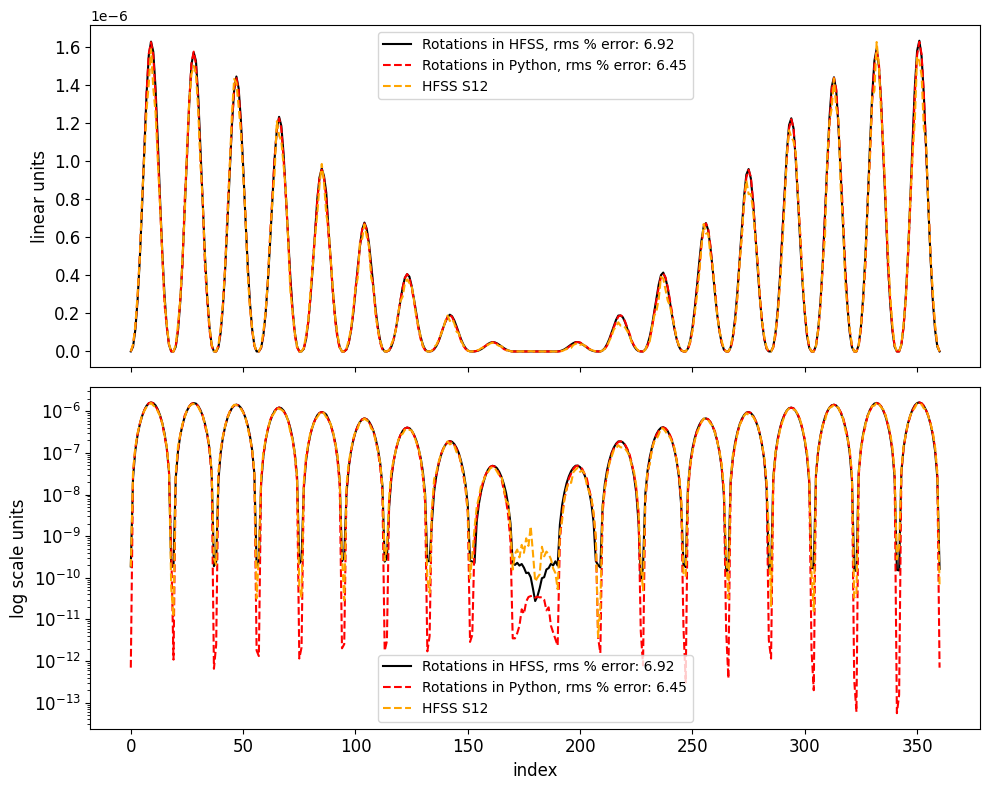

In [289]:
s11_b100 = 1-10**(s11_bowtie[:, 50]/10)
s11_t100 = 1-10**(s11_t[:, 50]/10)

P_meas = 10**(s12_bowtie[:, 50]/10)
P_pred = P * s11_b100 / scale_factor[:, rx_px]
P_mine_s11 = P_mine * s11_b100 / scale_factor[:, rx_px] 


# plt.figure(figsize=(10, 6))
# plt.plot(P_pred, color='black', label=f'Rotations in HFSS, rms % error:{(rms_err(P_pred, P_meas)*100):.3g}')
# plt.plot(P_mine_s11, color='red', ls='--', label=f'Rotations in Python, rms % error:{(rms_err(P_mine_s11, P_meas)*100):.3g}')
# plt.plot(P_meas, color='orange', ls='--', label='hfss')
# plt.xlabel('index', fontsize=12)
# plt.ylabel('linear units', fontsize=12)
# plt.legend()
# plt.tick_params(labelsize=12)
# plt.tight_layout()
# # plt.savefig(save_path + 'hfss_sim_copmarisons.png')
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.semilogy(P_pred, label=f'sim w/ different rotated beams, rm error:{rms_err(P_pred, P_meas):.3g}')
# plt.semilogy(P_mine_s11, ls='--', label=f'sim w/ single beam rotated, rms error:{rms_err(P_mine_s11, P_meas):.3g}')
# plt.semilogy(P_meas, ls='--', label='hfss')
# plt.xlabel('index')
# plt.ylabel('log units')
# plt.legend()
# plt.savefig(save_path + 'log_comp.png')
# plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

label_pred = f'Rotations in HFSS, rms % error: {(rms_err(P_pred, P_meas)*100):.3g}'
label_mine = f'Rotations in Python, rms % error: {(rms_err(P_mine_s11, P_meas)*100):.3g}'
label_meas = 'HFSS S12'

# Left: linear scale
axes[0].plot(P_pred, color='black', label=label_pred)
axes[0].plot(P_mine_s11, color='red', ls='--', label=label_mine)
axes[0].plot(P_meas, color='orange', ls='--', label=label_meas)
# axes[0].set_xlabel('index', fontsize=12)
axes[0].set_ylabel('linear units', fontsize=12)
# axes[0].set_title('Linear scale', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].tick_params(labelsize=12)

# Right: log scale
axes[1].semilogy(P_pred, color='black', label=label_pred)
axes[1].semilogy(P_mine_s11, color='red', ls='--', label=label_mine)
axes[1].semilogy(P_meas, color='orange', ls='--', label=label_meas)
axes[1].set_xlabel('index', fontsize=12)
axes[1].set_ylabel('log scale units', fontsize=12)
# axes[1].set_title('Log scale', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig(save_path + 'hfss_sim_comparisons.png')
plt.show()

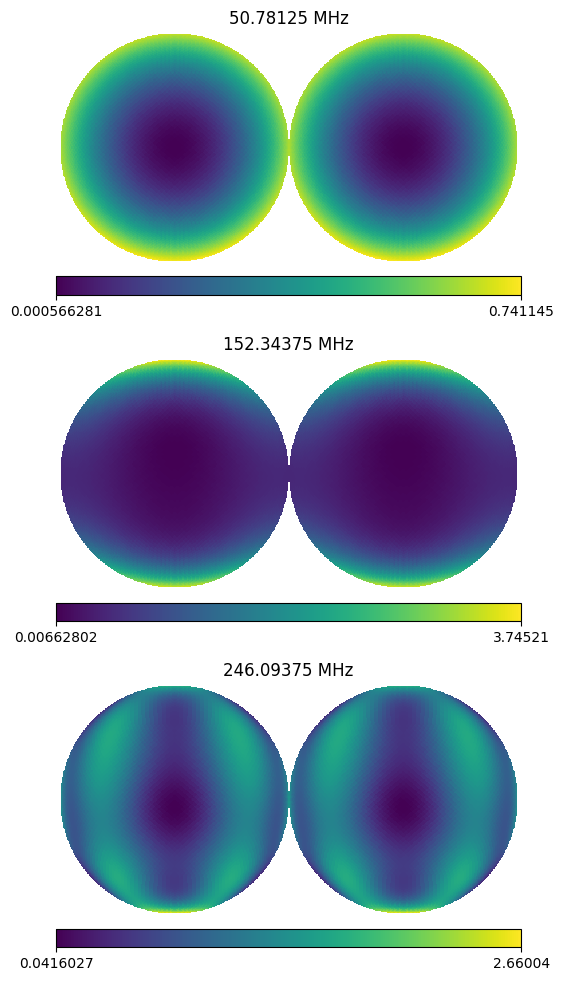

In [137]:


# hp.orthview(gain_maps[0], title=f'{rot_freq[0]} MHz')
# hp.orthview(gain_maps[23], title=f'{rot_freq[23]} MHz')
# hp.orthview(gain_maps[-1], title=f'{rot_freq[-1]} MHz')

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

plt.sca(axs[0])
hp.orthview(
    gain_maps[0],
    title=f'{rot_freq[0]} MHz',
    hold=True,
    cbar=True
)

plt.sca(axs[1])
hp.orthview(
    gain_maps[26],
    title=f'{rot_freq[26]} MHz',
    hold=True,
    cbar=True
)

plt.sca(axs[2])
hp.orthview(
    gain_maps[-1],
    title=f'{rot_freq[-1]} MHz',
    hold=True,
    cbar=True
)

# plt.tight_layout()
plt.show()

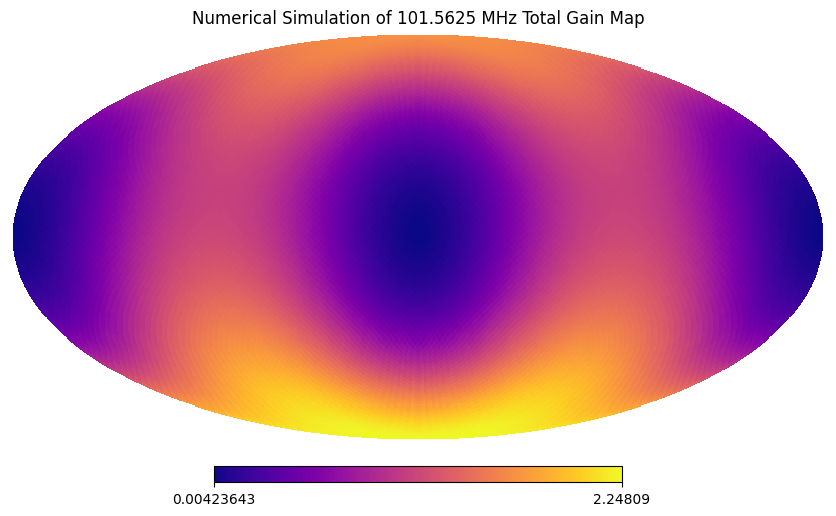

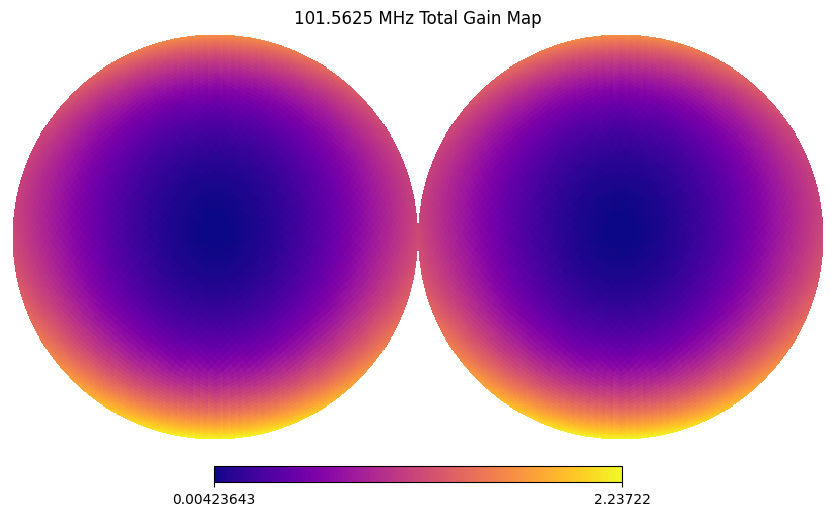

In [244]:
hp.mollview(gain_maps[fig_ind], title=f'Numerical Simulation of {fig_freq} MHz Total Gain Map', cmap='plasma')
plt.savefig('/Users/dominiv/sfsu/cose2026/figures/total_gain_map.png')
hp.orthview(gain_maps[fig_ind], title=f'{fig_freq} MHz Total Gain Map', cmap='plasma')

## Dirac Comb in Code

In [138]:
waveform = np.load('/Users/dominiv/eigsep/DAC/notebooks/transmitter.npz')

In [147]:
freqs.shape

(1024,)

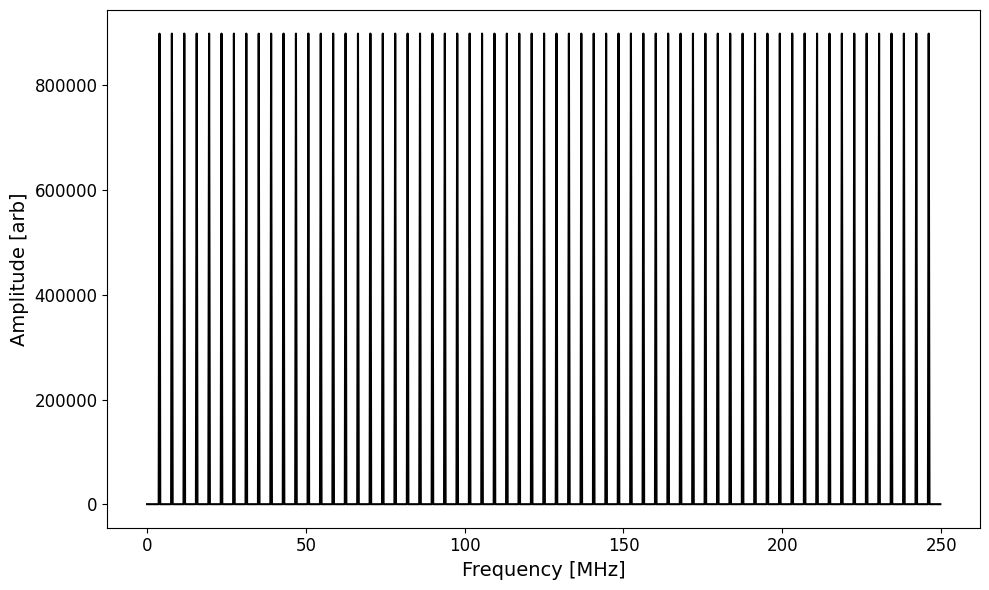

In [181]:
fft_wave = np.abs(np.fft.fft(waveform['data']))

# plt.figure()
# plt.plot((freqs), np.fft.fftshift(fft_wave)[2048:2048+1024])
# plt.
# plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.plot(freqs, np.fft.fftshift(fft_wave)[2048:2048+1024], color='black')
ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Amplitude [arb]", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
# plt.savefig('/Users/dominiv/sfsu/thesis/figures/dirac_comb.pdf')
plt.show()

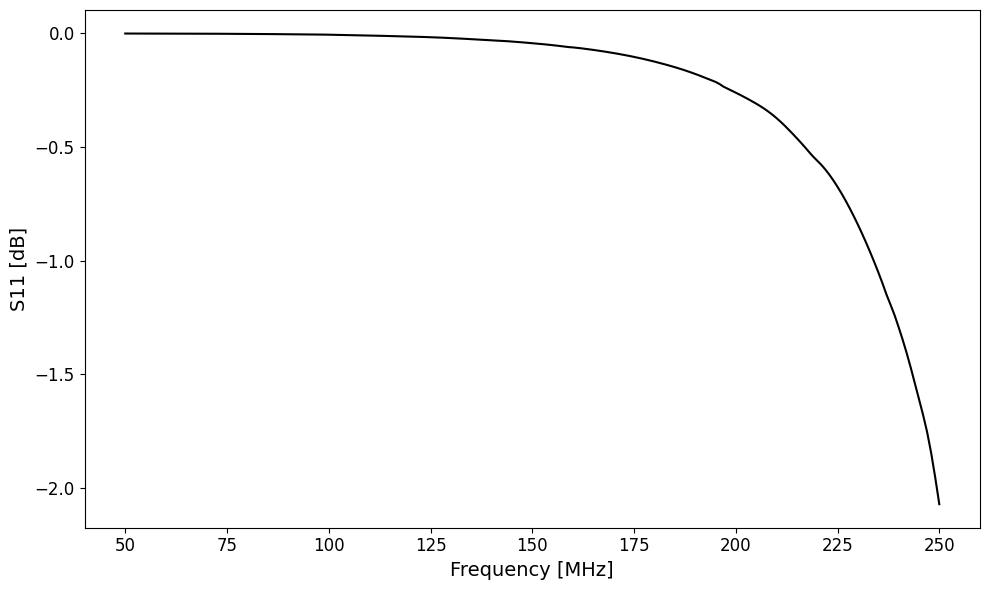

In [180]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361

phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])
freqs_hfss = s11_transmitter[:inc, 2]

def db_lin(db):
    # return 10**(db/10)
    return db

s11_t = db_lin(s11_transmitter[:, 3])
s11_t = s11_t.reshape(ang, inc)


fig, ax = plt.subplots(figsize=(10, 6))
im = ax.plot(freqs_hfss, s11_t[9, :], color='black')
ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("S11 [dB]", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig('/Users/dominiv/sfsu/thesis/figures/s11_trans.pdf')
plt.show()

## Dirac Comb in SNAP

In [3]:
no_clock = np.load('/Users/dominiv/sfsu/thesis/data/no_clock.npz')
clock = np.load('/Users/dominiv/sfsu/thesis/data/clock.npz')

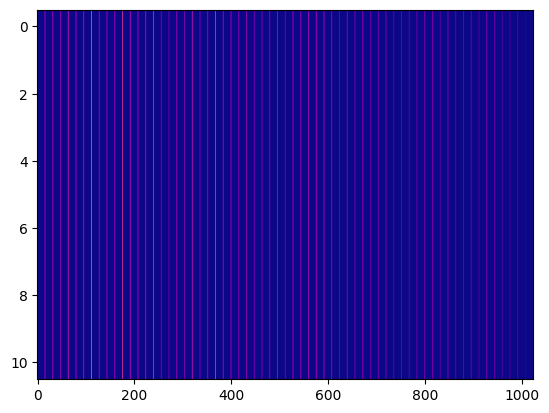

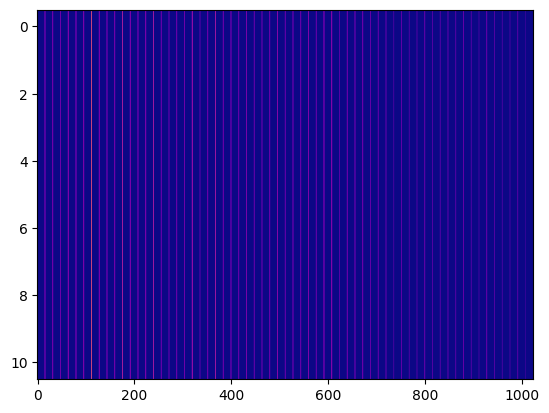

In [68]:
plt.figure()
plt.imshow(no_clock['0'][:, 0, :], aspect='auto', cmap='plasma')
plt.show()

plt.figure()
plt.imshow(clock['0'][:, 0, :], aspect='auto', cmap='plasma')
plt.show()

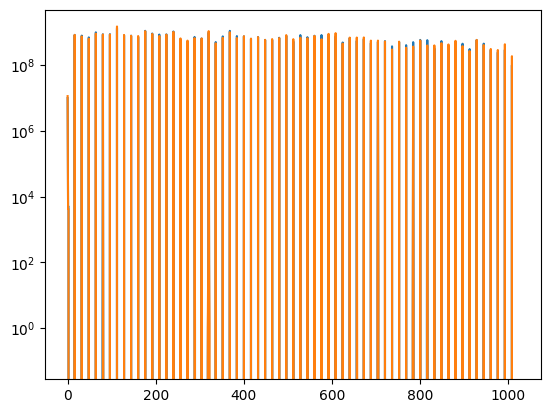

In [69]:
plt.figure()
plt.semilogy(np.mean(no_clock['0'][:, 0, :], axis=0))
plt.semilogy(np.mean(clock['0'][:, 0, :], axis=0))
# plt.semilogy(clock['0'][0, 0, :])
plt.show()

## Beam Maps